# Which Electoral Systems Reduce Polarization Over Time?

This notebook studies a harder question than the usual one-shot comparison of electoral systems. Instead of asking which system picks the best winner in a single election, it asks how different systems shape the political map over repeated elections.

The key idea is that polarization is not a single object. In a spatial model, polarization can grow because voters react against winners, because social sorting pulls groups into clearer camps, or because candidates learn that sharper differentiation helps them survive. So the notebook studies several simple polarization mechanisms and then asks how electoral systems behave under each one.

The notebook keeps voting non-strategic. Ballots are generated sincerely from spatial preferences. That keeps the focus on institutional feedback rather than on tactical ballot behavior. It also brings back two discrete `Fractional` benchmarks, not as real-world rules, but as useful distance-sensitive single-winner reference points for what sharper and softer nearest-candidate rules do over time.

A new design choice matters for the whole notebook. The same electorate profiles are now studied under three camp-balance settings: the original balance, a `70:30` majority-minority split, and a `50:50` split. The reason is not just to make the grid larger. It is to test whether apparent depolarization comes from mutual accommodation or from the smaller camp doing most of the moving.

---
## Imports and configuration



In [1]:
import importlib
import sys
from pathlib import Path

from IPython.display import display
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

cwd = Path.cwd().resolve()
if (cwd / "configs").exists() and (cwd / "electoral_sim").exists():
    REPO_ROOT = cwd
else:
    REPO_ROOT = cwd.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import notebooks.helpers.polarization_dynamics as polarization
polarization = importlib.reload(polarization)

ELECTORATE_ORDER = polarization.ELECTORATE_ORDER
CANDIDATE_ORDER = polarization.CANDIDATE_ORDER
RATIO_ORDER = polarization.RATIO_ORDER
VOTER_MODEL_ORDER = polarization.VOTER_MODEL_ORDER
CANDIDATE_MODEL_ORDER = polarization.CANDIDATE_MODEL_ORDER
SYSTEM_ORDER = polarization.SYSTEM_ORDER
ORACLE_ORDER = polarization.ORACLE_ORDER

build_polarization_electorate = polarization.build_polarization_electorate
build_polarization_candidates = polarization.build_polarization_candidates
polarization_helper_overview = polarization.polarization_helper_overview
illustrate_voter_mechanisms = polarization.illustrate_voter_mechanisms
illustrate_candidate_mechanisms = polarization.illustrate_candidate_mechanisms
run_polarization_trajectory = polarization.run_polarization_trajectory
summarize_trajectory_changes = polarization.summarize_trajectory_changes
run_polarization_comparison_grid = polarization.run_polarization_comparison_grid
run_polarization_trajectory_grid = polarization.run_polarization_trajectory_grid
run_oracle_trajectory = polarization.run_oracle_trajectory
trace_oracle_state = polarization.trace_oracle_state
compare_trajectory_to_baseline = polarization.compare_trajectory_to_baseline
plot_polarization_trajectories = polarization.plot_polarization_trajectories
plot_baseline_difference_trajectories = polarization.plot_baseline_difference_trajectories
plot_polarization_metric_heatmap = polarization.plot_polarization_metric_heatmap
plot_start_end_maps = polarization.plot_start_end_maps
plot_oracle_start_end_maps = polarization.plot_oracle_start_end_maps
plot_polarization_tradeoff_scatter = polarization.plot_polarization_tradeoff_scatter
plot_ratio_system_heatmap = polarization.plot_ratio_system_heatmap

sns.set_theme(style="whitegrid")
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)

BASE_SEED = 42
DIM_NAMES = ["economic", "social"]


---
## Preliminary setup

The notebook uses the same spatial interpretation as the rest of the repo. Voters and candidates are points in a shared two-dimensional map. Closer points mean greater ideological similarity.

What changes here is the time dimension. At each round:

1. the electorate votes sincerely under a chosen electoral system,
2. the system produces an outcome,
3. voters and candidates update their positions,
4. the next election is run from that new political map.

That makes the notebook a study of feedback loops rather than isolated elections.

The main polarization and representation metrics are:

- voter pairwise distance: the average distance between voters,
- candidate pairwise distance: how spread out the candidate field is,
- group-center gap: the average distance between labeled group centers,
- winner-to-center distance: how far the winning outcome sits from the electorate center,
- distance to the electorate median: how far the winning outcome sits from the electorate's geometric median.

To keep notation compact, let $x_i^t$ be voter $i$'s position at round $t$, let $c_j^t$ be candidate $j$'s position, let $w^t$ be the winning outcome, let $\bar{x}^t$ be the electorate mean, and let $m^t$ be the electorate geometric median.

For the new camp-balance design, the notebook also tracks how much the larger and smaller camps move. Let $\mu_{\mathrm{maj}}^t$ and $\mu_{\mathrm{min}}^t$ be the camp centers at round $t$. Then the notebook defines

$$
D_{\mathrm{maj}}^t = \|\mu_{\mathrm{maj}}^t - \mu_{\mathrm{maj}}^0\|,
\qquad
D_{\mathrm{min}}^t = \|\mu_{\mathrm{min}}^t - \mu_{\mathrm{min}}^0\|.
$$

The main asymmetry measure is the normalized displacement imbalance

$$
A^t = \frac{D_{\mathrm{min}}^t - D_{\mathrm{maj}}^t}{D_{\mathrm{min}}^t + D_{\mathrm{maj}}^t + \varepsilon}.
$$

If $A^t$ is near zero, the two camps are moving by similar amounts. If $A^t$ is strongly positive, the smaller camp is doing more of the moving. The notebook also tracks midpoint drift,

$$
C^t = \left\| \frac{\mu_{\mathrm{maj}}^t + \mu_{\mathrm{min}}^t}{2} - \frac{\mu_{\mathrm{maj}}^0 + \mu_{\mathrm{min}}^0}{2} \right\|,
$$

which helps distinguish genuine mutual accommodation from a case where the whole center of gravity drifts toward the majority side.

The ratio design is used for the same reason. If a system only looks depolarizing when one camp starts much smaller, that is evidence that the metric may be picking up asymmetric consolidation rather than mutual accommodation. In profiles with bridge voters, the bridge share is held fixed while the opposing camps are rescaled to `Original`, `70:30`, and `50:50`.

---
## Helper overview



In [2]:
polarization_helper_overview()


,component,options,purpose
0,Electorate profiles,"Two blocs, Bridge conflict, Asymmetric resentment",Starting voter landscapes for repeated-electio...
1,Candidate slates,"Centrist ladder, Polarized elites, Asymmetric ...",Initial elite configurations before strategic ...
2,Camp balance,"Original, 70:30, 50:50",Relative size of the two opposing camps; neutr...
3,Voter dynamics,"Consensus pull, Backlash, Sorting pressure",How voters move after each election under conv...
4,Candidate dynamics,"Static candidates, Broad coalition chase, Base...","How candidates respond to supporters, the elec..."
5,Polarization metrics,"dispersion, pairwise distance, PC1 bimodality,...",Summary metrics tracked over time alongside el...
6,Oracle benchmarks,"Geometric median oracle, Depolarization oracle",Unconstrained outcome benchmarks for geometric...


---
## The polarization mechanisms studied here

The notebook uses two kinds of mechanisms. They should be read as stylized feedback loops: an election produces an outcome, voters and candidates react to that outcome, and the next election is then held in a slightly changed political landscape. So the "polarization mechanisms" here are not direct claims about media, party organizations, or identity formation by themselves. They are compact spatial stories about how repeated elections can either cool conflict or harden it.

For voters, the update rule is built from the electorate center and the winning outcome:

$$
x_i^{t+1} = x_i^t + \alpha (\bar{x}^t - x_i^t) + \beta (w^t - x_i^t) - \gamma_i^t (w^t - x_i^t) + \varepsilon_i^t.
$$

Here $\alpha$ is social pull toward the center, $\beta$ is attraction toward the winner, and $\gamma_i^t$ is a backlash term that becomes larger when voter $i$ is far from the winner. In plain language, the first two terms describe convergence pressures, while the backlash term describes alienation from outcomes that feel too far away.

The voter mechanisms are:

- `Consensus pull`: this is the kind of environment one might associate with broad legitimacy, weak partisan identity, or a political culture where most people still adjust somewhat toward shared institutions. In parameters, it uses relatively large center-seeking and winner-seeking terms with almost no backlash: `social_pull=0.08`, `winner_pull=0.06`, `backlash_pull=0.00`, `backlash_threshold=0.30`, `noise_scale=0.002`.
- `Backlash`: this is meant to capture a setting where voters sometimes accept outcomes but push away from winners they see as too distant. That could correspond to polarized media environments, protest voting, or disappointed coalitions that become less accommodating after losing. In parameters, the convergence terms are weaker and backlash is active once the winner is not very close: `social_pull=0.03`, `winner_pull=0.02`, `backlash_pull=0.08`, `backlash_threshold=0.16`, `noise_scale=0.003`.
- `Sorting pressure`: this is the hardestening case. It stands in for a world where partisan or group identities are strong enough that distant winners mainly trigger further separation rather than adaptation. In parameters, the convergent forces are weakest and backlash is strongest: `social_pull=0.02`, `winner_pull=0.01`, `backlash_pull=0.11`, `backlash_threshold=0.12`, `noise_scale=0.004`.

For candidates, the update rule is built from each candidate's supporter center, the electorate center, and nearby rivals:

$$
c_j^{t+1} = c_j^t + \lambda (s_j^t - c_j^t) + \mu (\bar{x}^t - c_j^t) + \nu r_j^t,
$$

where $s_j^t$ is the average position of candidate $j$'s supporters and $r_j^t$ is a repulsion term pushing the candidate away from a nearby rival. These are meant to capture three familiar political incentives: listening to the base, chasing a wider coalition, and differentiating from close competitors.

The candidate mechanisms are:

- `Static candidates`: this is the no-adaptation baseline. It fits situations where party labels, incumbency, or institutional rigidity keep the candidate menu fixed across rounds. In parameters, all movement terms are zero: `supporter_pull=0.00`, `electorate_pull=0.00`, `differentiation_pull=0.00`.
- `Broad coalition chase`: this corresponds to a world where elites respond to supporters but still feel pressure to move toward the electorate center, as might happen in systems that reward moderation or general-election breadth. In parameters, both supporter pull and electorate pull are active, while rival repulsion is mild: `supporter_pull=0.12`, `electorate_pull=0.08`, `differentiation_pull=0.02`.
- `Base reinforcement`: this is the more combative case, where candidates listen more to their own supporters and work harder to separate themselves from nearby rivals. That can stand in for primary pressure, activist capture, or elite differentiation in crowded polarized fields. In parameters, supporter pull and rival repulsion are stronger while electorate pull is almost absent: `supporter_pull=0.18`, `electorate_pull=0.01`, `differentiation_pull=0.06`.

Taken together, these mechanisms say what kind of political world is being simulated after each election. A low-polarization mechanism means outcomes tend to pull people and elites inward. A high-polarization mechanism means outcomes trigger backlash, sorting, and differentiation that can keep widening political distance.

In [3]:
example_electorate = build_polarization_electorate(
    "Bridge conflict",
    seed=BASE_SEED,
    dim_names=DIM_NAMES,
    n_voters=1200,
)
example_candidates = build_polarization_candidates("Centrist ladder")
illustration_winner = example_candidates.positions[2]

print("Representative electorate:", "Bridge conflict")
print("Representative candidate slate:", "Centrist ladder")
print("Illustration winner position:", illustration_winner.round(3))


Representative electorate: Bridge conflict
Representative candidate slate: Centrist ladder
Illustration winner position: [0.46 0.5 ]


### How voters move under the different voter mechanisms

The next figure keeps the winner fixed and applies each voter mechanism repeatedly for 50 rounds. So each row is a start-versus-end illustration of what that mechanism would do on its own, before any electoral-system comparison is layered on top.



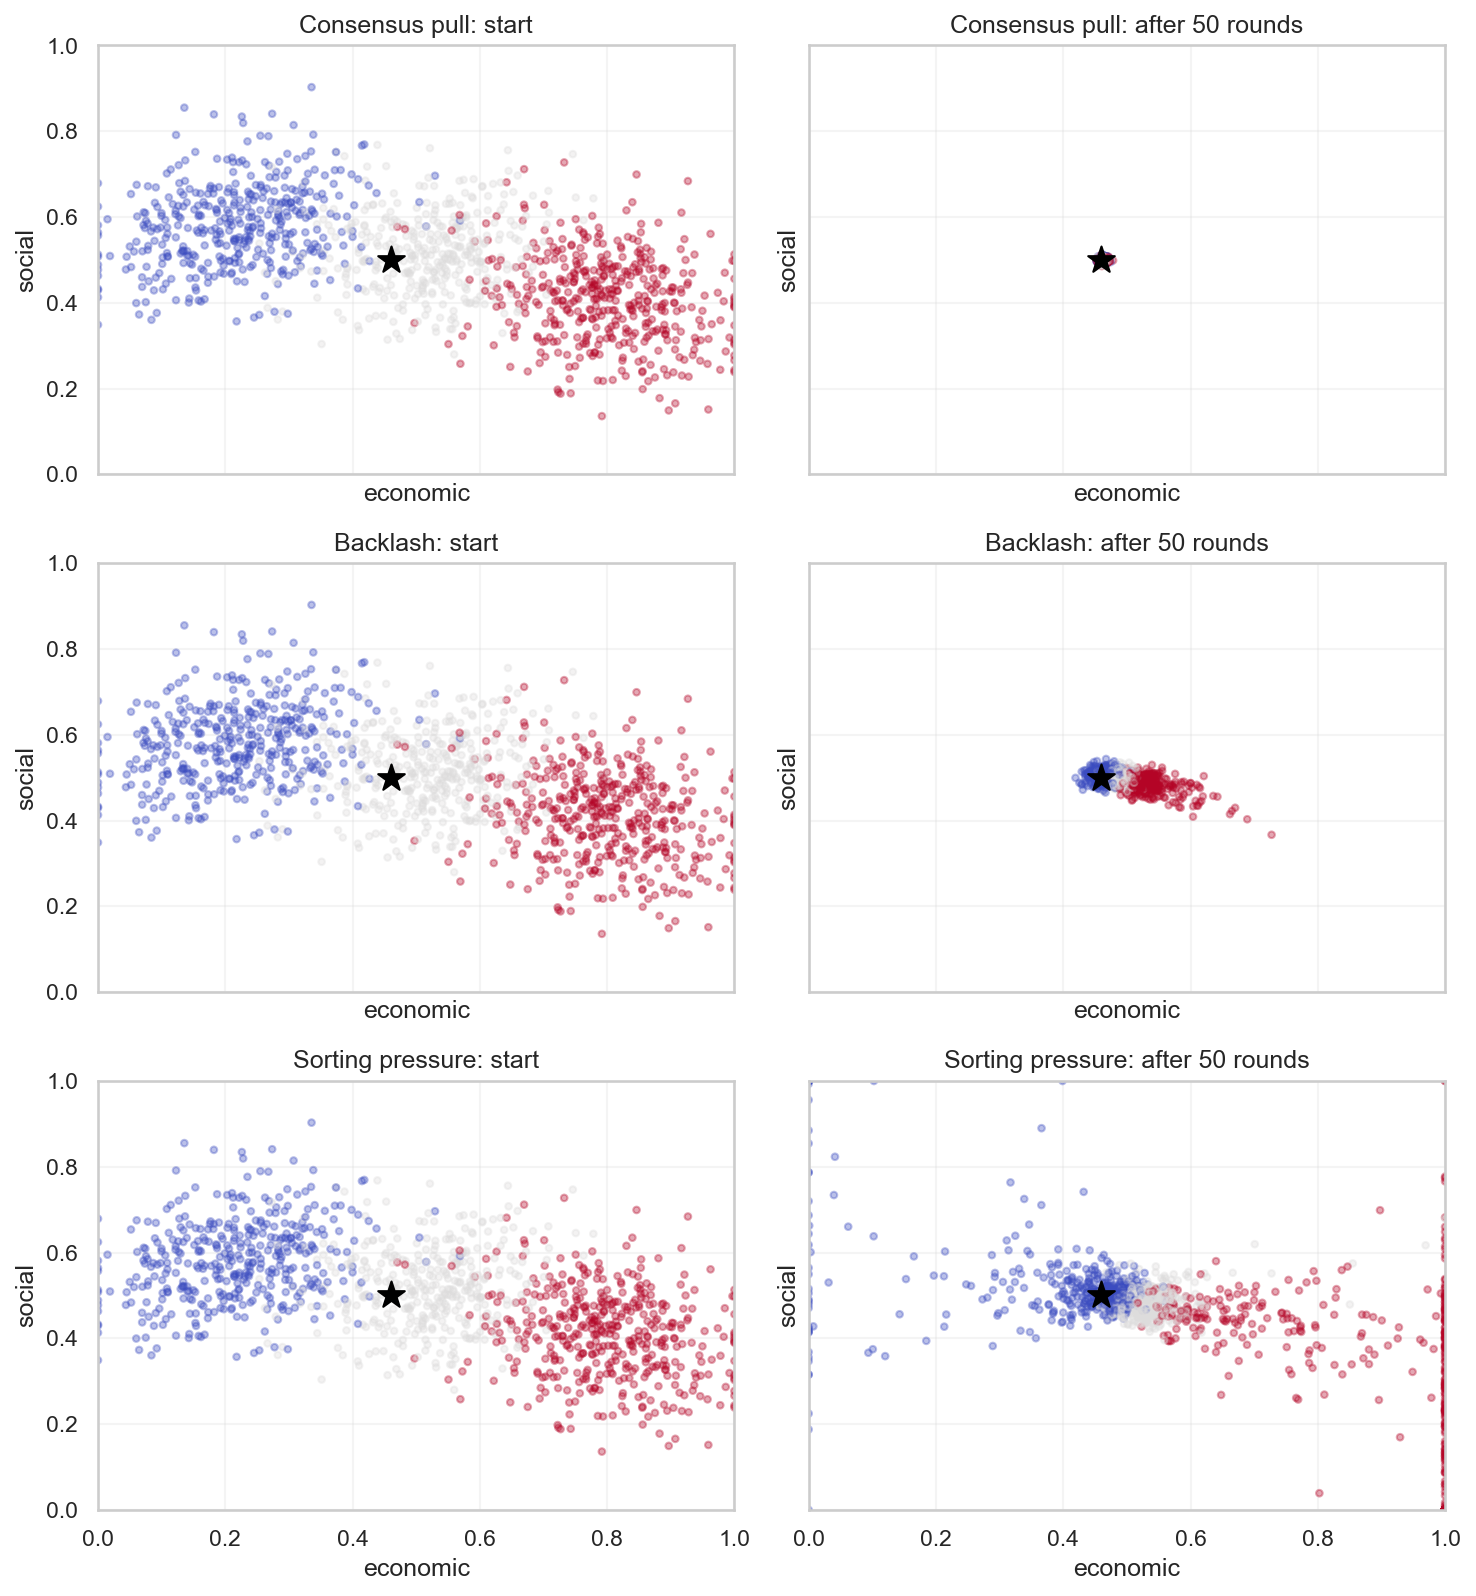

In [4]:
illustrate_voter_mechanisms(
    example_electorate,
    winner_position=illustration_winner,
    model_names=VOTER_MODEL_ORDER,
    n_rounds=50,
    seed=BASE_SEED,
);


### How candidates move under the different candidate mechanisms

This figure does the same thing for candidates. The gray cloud is the electorate. Each row shows the same starting slate and the slate after 50 rounds of repeated candidate updating under that mechanism.



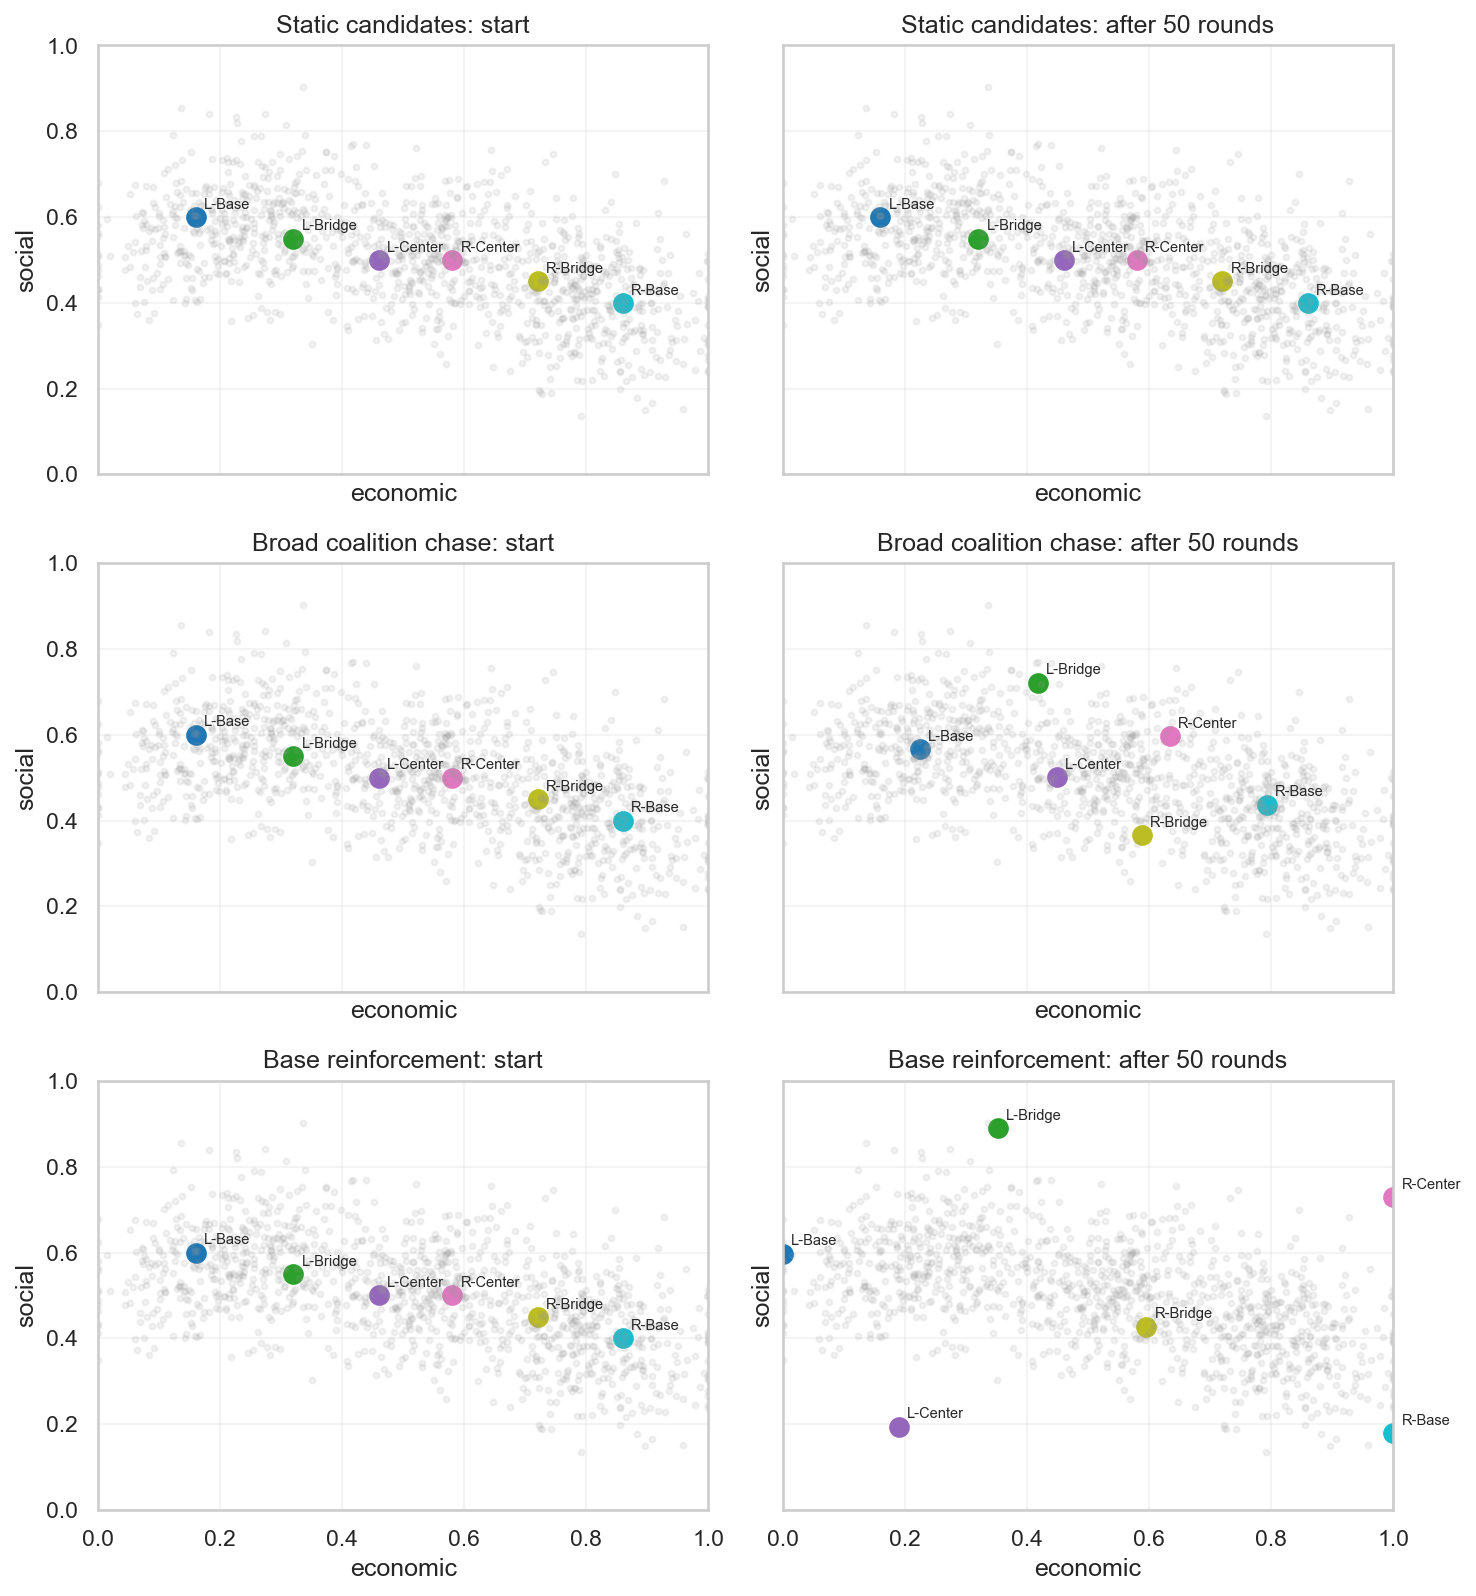

In [5]:
illustrate_candidate_mechanisms(
    example_electorate,
    example_candidates,
    model_names=CANDIDATE_MODEL_ORDER,
    n_rounds=50,
);


---
## Electoral systems included

The notebook compares:

- `Plurality`
- `IRV`
- `Approval`
- `Score`
- `Condorcet`
- `Fractional (sigma=0.3)`
- `Fractional (sigma=1.0)`

The first five are familiar candidate-centered systems. The two `Fractional` entries are included as benchmarks. They are not meant to represent currently deployed electoral rules. In this notebook both use the discrete fractional variant, so support is allocated across the existing candidate menu and then summarized back into a single outcome position. The smaller sigma concentrates weight more strongly on nearby candidates, while the larger sigma spreads weight more broadly across the field. That makes the pair useful for seeing how the sharpness of distance weighting changes the long-run dynamics.

That also means winners are handled a little differently in the repeated-election simulation. For winner-take-all systems like `Plurality`, `IRV`, `Approval`, `Score`, and `Condorcet`, the dynamic update uses the realized winning candidate position $w^t$. For the discrete fractional rule, voters distribute weight across candidates, and the simulator feeds back the rule's `outcome_position`, which is the weighted centroid of the candidate positions under those fractional weights. So the next round responds to an aggregate candidate-weighted outcome rather than to one named winner alone.

In proportional-representation language, the dynamic loop therefore uses the policy summary of the elected bundle, not just the median legislator or the top-weight candidate. The simulator still records auxiliary winner fields for compatibility, but in these dynamic experiments the feedback mechanism always uses `outcome_position` itself. So the fractional benchmarks should be read as discrete candidate-menu aggregation rules, not as standard winner-take-all systems.

Each of those systems is now evaluated under three camp-balance settings: `Original`, `70:30`, and `50:50`. That extra design dimension is there so the notebook can test whether a system's apparent depolarization survives once the larger-versus-smaller-camp structure is changed.

---
## How systems diverge from plurality over time

A single representative trajectory is useful for intuition, but it is a weak basis for comparison. The next figure instead follows the full grid of mechanism combinations over time and uses plurality as the baseline at each round. That grid now varies not only electorate shape, candidate slate, and update mechanism, but also the `Original`, `70:30`, and `50:50` camp-balance settings.

For each metric $M$, the line for system $s$ at round $t$ is

$$
D_{s,M}^{t} = M_s^{t} - M_{\text{Plurality}}^{t}.
$$

The solid line is the median across all sampled mechanism combinations. The shaded band is the interquartile range. That means the figure is showing where systems typically sit relative to plurality, not just what happens in one hand-picked case.

Because all four plotted metrics are quantities where lower is better, values below zero indicate that the system is improving on plurality at that round. Values above zero indicate that the system is doing worse than plurality on that metric.

In [6]:
trajectory_grid_df = run_polarization_trajectory_grid(
    electorate_names=ELECTORATE_ORDER,
    ratio_names=RATIO_ORDER,
    candidate_names=["Centrist ladder", "Polarized elites"],
    voter_dynamics_names=VOTER_MODEL_ORDER,
    candidate_dynamics_names=CANDIDATE_MODEL_ORDER,
    system_names=SYSTEM_ORDER,
    n_steps=50,
    n_voters=900,
    seed=BASE_SEED,
)

relative_trajectory_df = compare_trajectory_to_baseline(
    trajectory_grid_df,
    baseline_system="Plurality",
    metrics=[
        "voter_pairwise_distance",
        "candidate_pairwise_distance",
        "winner_to_center_distance",
        "distance_to_median",
    ],
)

relative_trajectory_df.head()

,system,step,winner,outcome_position,distance_to_median,mean_voter_distance,majority_satisfaction,ratio,voter_dispersion,voter_pairwise_distance,voter_p90_distance,pc1_bimodality,group_center_gap,candidate_pairwise_distance,winner_to_center_distance,camp_a_displacement,camp_b_displacement,majority_camp_displacement,minority_camp_displacement,displacement_asymmetry_ratio,normalized_displacement_asymmetry,coalition_gap,coalition_gap_change,coalition_midpoint_drift,majority_share,case_id,electorate,candidate_slate,voter_dynamics,candidate_dynamics,voter_pairwise_distance_baseline,candidate_pairwise_distance_baseline,winner_to_center_distance_baseline,distance_to_median_baseline,voter_pairwise_distance_vs_Plurality,candidate_pairwise_distance_vs_Plurality,winner_to_center_distance_vs_Plurality,distance_to_median_vs_Plurality
0,Plurality,0,L-Base,"[0.16, 0.6]",0.365490,0.398532,0.232222,Original,0.288500,0.368525,0.420306,5.024493,0.364044,0.333417,0.361665,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.545972,0.000000,0.000000,0.514943,0,Two blocs,Centrist ladder,Consensus pull,Static candidates,0.368525,0.333417,0.361665,0.365490,0.0,0.0,0.0,0.0
1,Plurality,1,R-Bridge,"[0.72, 0.45]",0.236512,0.295568,0.280000,Original,0.248119,0.324596,0.360774,5.024808,0.313058,0.333417,0.240223,0.017545,0.058928,0.058928,0.017545,0.297740,-0.541141,0.469501,-0.076471,0.020694,0.514943,0,Two blocs,Centrist ladder,Consensus pull,Static candidates,0.324596,0.333417,0.240223,0.236512,0.0,0.0,0.0,0.0
2,Plurality,2,L-Bridge,"[0.32, 0.55]",0.189650,0.246084,0.332222,Original,0.213334,0.280487,0.308811,5.021007,0.269141,0.333417,0.186775,0.065688,0.076667,0.076667,0.065688,0.856798,-0.077123,0.403644,-0.142328,0.005661,0.514943,0,Two blocs,Centrist ladder,Consensus pull,Static candidates,0.280487,0.333417,0.186775,0.189650,0.0,0.0,0.0,0.0
3,Plurality,3,L-Bridge,"[0.32, 0.55]",0.178192,0.218740,0.368889,Original,0.183489,0.236726,0.266379,5.022403,0.231566,0.333417,0.175476,0.083261,0.115430,0.115430,0.083261,0.721313,-0.161904,0.347302,-0.198670,0.016151,0.514943,0,Two blocs,Centrist ladder,Consensus pull,Static candidates,0.236726,0.333417,0.175476,0.178192,0.0,0.0,0.0,0.0
4,Plurality,4,L-Bridge,"[0.32, 0.55]",0.167369,0.195900,0.395556,Original,0.157704,0.201366,0.230447,5.011296,0.199017,0.333417,0.165016,0.097812,0.149690,0.149690,0.097812,0.653427,-0.209609,0.298491,-0.247480,0.025990,0.514943,0,Two blocs,Centrist ladder,Consensus pull,Static candidates,0.201366,0.333417,0.165016,0.167369,0.0,0.0,0.0,0.0


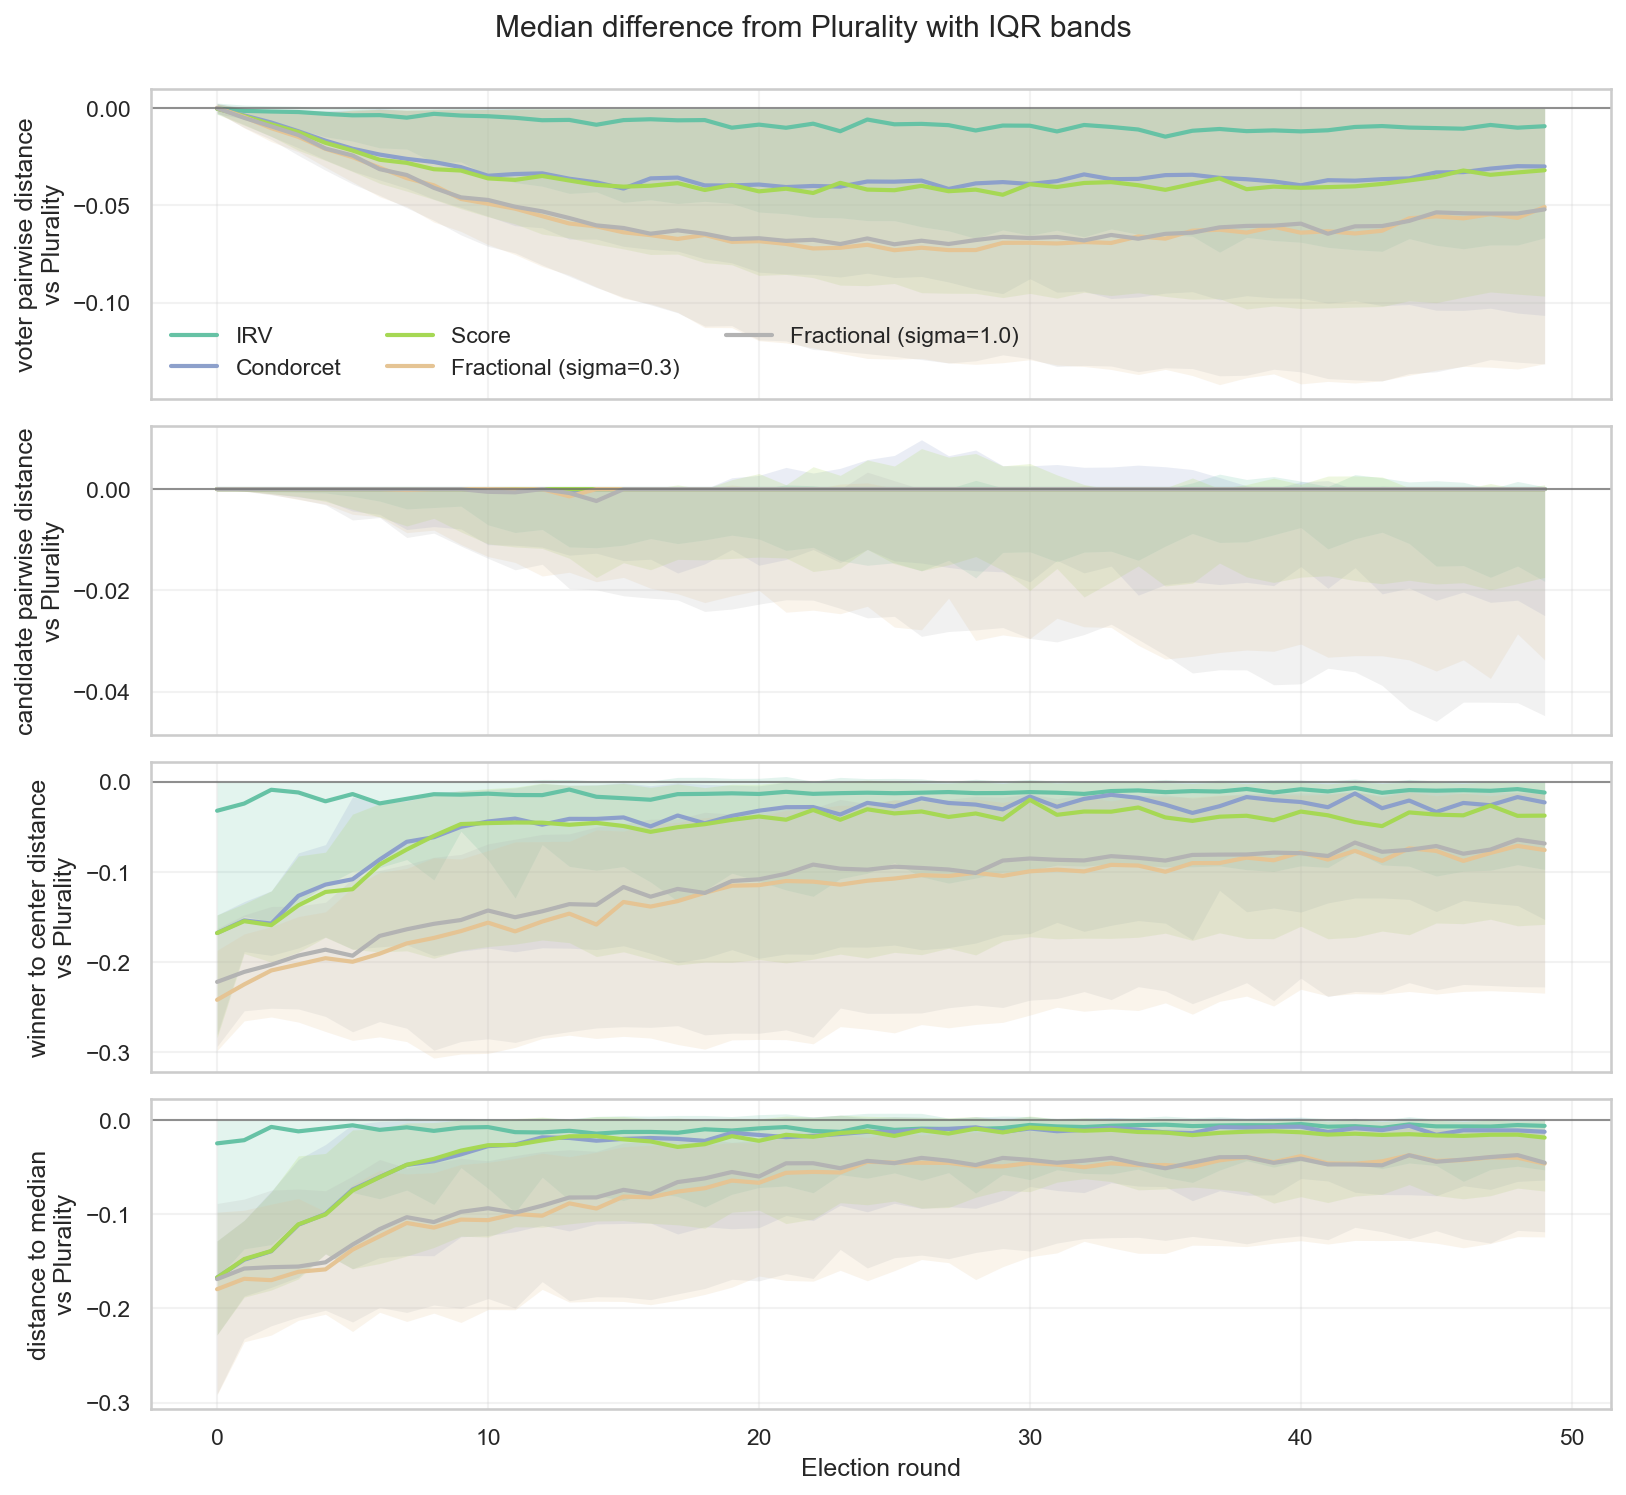

In [7]:
plot_baseline_difference_trajectories(
    relative_trajectory_df,
    baseline_system="Plurality",
    metrics=[
        "voter_pairwise_distance_vs_Plurality",
        "candidate_pairwise_distance_vs_Plurality",
        "winner_to_center_distance_vs_Plurality",
        "distance_to_median_vs_Plurality",
    ],
    systems=[
        "IRV",
        "Condorcet",
        "Score",
        "Fractional (sigma=0.3)",
        "Fractional (sigma=1.0)",
    ],
);

Here, we see that the voter- and candidate-polarization panels, the fractional variants, `Score`, and `Condorcet` can be compared directly against plurality as time passes. In the winner-centering panels, the same systems can be judged on whether that depolarization comes with more centered or less centered winners.

In [8]:
round50_relative_summary = (
    relative_trajectory_df[relative_trajectory_df["step"] == relative_trajectory_df["step"].max()]
    .groupby("system", as_index=False)
    .agg(
        median_voter_pairwise_vs_plurality=("voter_pairwise_distance_vs_Plurality", "median"),
        median_candidate_pairwise_vs_plurality=("candidate_pairwise_distance_vs_Plurality", "median"),
        median_winner_center_vs_plurality=("winner_to_center_distance_vs_Plurality", "median"),
        median_distance_to_median_vs_plurality=("distance_to_median_vs_Plurality", "median"),
    )
    .sort_values("median_voter_pairwise_vs_plurality")
    .reset_index(drop=True)
)
round50_relative_summary

,system,median_voter_pairwise_vs_plurality,median_candidate_pairwise_vs_plurality,median_winner_center_vs_plurality,median_distance_to_median_vs_plurality
0,Fractional (sigma=1.0),-0.052029,0.0,-0.068348,-0.045306
1,Fractional (sigma=0.3),-0.050806,0.0,-0.075608,-0.046261
2,Score,-0.031882,0.0,-0.037437,-0.018671
3,Condorcet,-0.029946,0.0,-0.022799,-0.012497
4,IRV,-0.009242,0.0,-0.011863,-0.006212
5,Approval,-0.001551,0.0,-0.005663,-0.001465
6,Plurality,0.000000,0.0,0.000000,0.000000


---
## Comparing systems across many polarization mechanisms

The next step expands beyond the trajectory view and summarizes start-to-end changes. The notebook averages over:

- three starting electorates,
- three camp-balance settings,
- two candidate slates,
- three voter mechanisms,
- three candidate mechanisms,
- and all seven electoral systems.

Each run is followed for 50 rounds. This does not exhaust every possible setup, but it is broad enough to show whether a system only looks good in one narrow corner or stays relatively stable across several plausible polarization stories and camp balances.

In [9]:
comparison_df = run_polarization_comparison_grid(
    electorate_names=ELECTORATE_ORDER,
    ratio_names=RATIO_ORDER,
    candidate_names=["Centrist ladder", "Polarized elites"],
    voter_dynamics_names=VOTER_MODEL_ORDER,
    candidate_dynamics_names=CANDIDATE_MODEL_ORDER,
    system_names=SYSTEM_ORDER,
    n_steps=50,
    n_voters=900,
    seed=BASE_SEED,
)

comparison_df.head()

,system,start_winner,end_winner,n_steps,distance_to_median_start,distance_to_median_end,distance_to_median_delta,mean_voter_distance_start,mean_voter_distance_end,mean_voter_distance_delta,majority_satisfaction_start,majority_satisfaction_end,majority_satisfaction_delta,voter_dispersion_start,voter_dispersion_end,voter_dispersion_delta,voter_pairwise_distance_start,voter_pairwise_distance_end,voter_pairwise_distance_delta,voter_p90_distance_start,voter_p90_distance_end,voter_p90_distance_delta,pc1_bimodality_start,pc1_bimodality_end,pc1_bimodality_delta,group_center_gap_start,group_center_gap_end,group_center_gap_delta,candidate_pairwise_distance_start,candidate_pairwise_distance_end,candidate_pairwise_distance_delta,winner_to_center_distance_start,winner_to_center_distance_end,winner_to_center_distance_delta,camp_a_displacement_start,camp_a_displacement_end,camp_a_displacement_delta,camp_b_displacement_start,camp_b_displacement_end,camp_b_displacement_delta,majority_camp_displacement_start,majority_camp_displacement_end,majority_camp_displacement_delta,minority_camp_displacement_start,minority_camp_displacement_end,minority_camp_displacement_delta,displacement_asymmetry_ratio_start,displacement_asymmetry_ratio_end,displacement_asymmetry_ratio_delta,normalized_displacement_asymmetry_start,normalized_displacement_asymmetry_end,normalized_displacement_asymmetry_delta,coalition_gap_start,coalition_gap_end,coalition_gap_delta,coalition_gap_change_start,coalition_gap_change_end,coalition_gap_change_delta,coalition_midpoint_drift_start,coalition_midpoint_drift_end,coalition_midpoint_drift_delta,majority_share_start,majority_share_end,majority_share_delta,case_id,electorate,ratio,candidate_slate,voter_dynamics,candidate_dynamics
0,Plurality,L-Base,L-Center,50,0.365490,0.002241,-0.363249,0.398532,0.005409,-0.393122,0.232222,1.0,0.767778,0.2885,0.005009,-0.283491,0.368525,0.007152,-0.361373,0.420306,0.008521,-0.411785,5.024493,2.645568,-2.378925,0.364044,0.000449,-0.363596,0.333417,0.333417,0.0,0.361665,0.002249,-0.359417,0.0,0.235581,0.235581,0.0,0.310003,0.310003,0.0,0.310003,0.310003,0.0,0.235581,0.235581,0.0,0.759931,0.759931,0.0,-0.136408,-0.136408,0.545972,0.000543,-0.545428,0.0,-0.545428,-0.545428,0.0,0.037626,0.037626,0.514943,0.514943,0.0,0,Two blocs,Original,Centrist ladder,Consensus pull,Static candidates
1,IRV,R-Bridge,R-Center,50,0.214481,0.003186,-0.211295,0.317396,0.005581,-0.311815,0.224444,1.0,0.775556,0.2885,0.004778,-0.283723,0.376030,0.006762,-0.369268,0.420306,0.008214,-0.412092,5.024493,2.662245,-2.362248,0.364044,0.000465,-0.363579,0.333417,0.333417,0.0,0.218644,0.003188,-0.215456,0.0,0.347565,0.347565,0.0,0.200166,0.200166,0.0,0.200166,0.200166,0.0,0.347565,0.347565,0.0,1.736382,1.736382,0.0,0.269108,0.269108,0.545972,0.000528,-0.545444,0.0,-0.545444,-0.545444,0.0,0.077777,0.077777,0.514943,0.514943,0.0,0,Two blocs,Original,Centrist ladder,Consensus pull,Static candidates
2,Approval,R-Bridge,L-Center,50,0.214481,0.003555,-0.210926,0.317396,0.005831,-0.311566,0.224444,1.0,0.775556,0.2885,0.004807,-0.283694,0.367415,0.006836,-0.360579,0.420306,0.008299,-0.412007,5.024493,2.527083,-2.497410,0.364044,0.000737,-0.363308,0.333417,0.333417,0.0,0.218644,0.003584,-0.215061,0.0,0.237410,0.237410,0.0,0.308355,0.308355,0.0,0.308355,0.308355,0.0,0.237410,0.237410,0.0,0.769925,0.769925,0.0,-0.129991,-0.129991,0.545972,0.000379,-0.545593,0.0,-0.545593,-0.545593,0.0,0.035957,0.035957,0.514943,0.514943,0.0,0,Two blocs,Original,Centrist ladder,Consensus pull,Static candidates
3,Score,L-Center,L-Center,50,0.050970,0.002052,-0.048918,0.289804,0.005239,-0.284565,0.042222,1.0,0.957778,0.2885,0.004909,-0.283592,0.370457,0.006994,-0.363463,0.420306,0.008299,-0.412007,5.024493,2.676983,-2.347510,0.364044,0.000460,-0.363584,0.333417,0.333417,0.0,0.046257,0.001937,-0.044320,0.0,0.235986,0.235986,0.0,0.309960,0.309960,0.0,0.309960,0.309960,0.0,0.235986,0.235986,0.0,0.761345,0.761345,0.0,-0.135496,-0.135496,0.545972,0.000209,-0.545762,0.0,-

In [10]:
system_summary = (
    comparison_df.groupby("system", as_index=False)
    .agg(
        mean_voter_pairwise_delta=("voter_pairwise_distance_delta", "mean"),
        mean_candidate_pairwise_delta=("candidate_pairwise_distance_delta", "mean"),
        mean_group_gap_delta=("group_center_gap_delta", "mean"),
        mean_normalized_displacement_asymmetry_end=("normalized_displacement_asymmetry_end", "mean"),
        mean_coalition_midpoint_drift_end=("coalition_midpoint_drift_end", "mean"),
        mean_winner_center_delta=("winner_to_center_distance_delta", "mean"),
        mean_distance_to_median_delta=("distance_to_median_delta", "mean"),
    )
    .reset_index(drop=True)
)

depolarization_summary = system_summary[
    [
        "system",
        "mean_voter_pairwise_delta",
        "mean_group_gap_delta",
        "mean_candidate_pairwise_delta",
    ]
].sort_values(
    ["mean_voter_pairwise_delta", "mean_group_gap_delta", "mean_candidate_pairwise_delta"]
).reset_index(drop=True)

ratio_focus_summary = (
    comparison_df.groupby(["ratio", "system"], as_index=False)
    .agg(
        mean_voter_pairwise_delta=("voter_pairwise_distance_delta", "mean"),
        mean_normalized_displacement_asymmetry_end=("normalized_displacement_asymmetry_end", "mean"),
        mean_coalition_midpoint_drift_end=("coalition_midpoint_drift_end", "mean"),
    )
)

representation_summary = system_summary[
    [
        "system",
        "mean_winner_center_delta",
        "mean_distance_to_median_delta",
    ]
].sort_values(
    ["mean_winner_center_delta", "mean_distance_to_median_delta"]
).reset_index(drop=True)


### Long-run depolarization

This section focuses on the first question: which systems cool the electorate itself over repeated elections? The tables and heatmaps below are about civic polarization, meaning how far apart voters and candidates end up in the spatial map, not just whether a given round's outcome sits near the center.

For these metrics, more negative values are better because they mean the quantity fell from the start of the trajectory to the end.

In [11]:
depolarization_summary

,system,mean_voter_pairwise_delta,mean_group_gap_delta,mean_candidate_pairwise_delta
0,Fractional (sigma=0.3),-0.228267,-0.260058,-0.002913
1,Fractional (sigma=1.0),-0.226119,-0.260318,-0.005009
2,Condorcet,-0.205231,-0.228318,0.003705
3,Score,-0.202565,-0.226939,0.006390
4,IRV,-0.191260,-0.203297,0.005035
5,Approval,-0.161761,-0.161835,0.008533
6,Plurality,-0.128692,-0.121459,0.016273


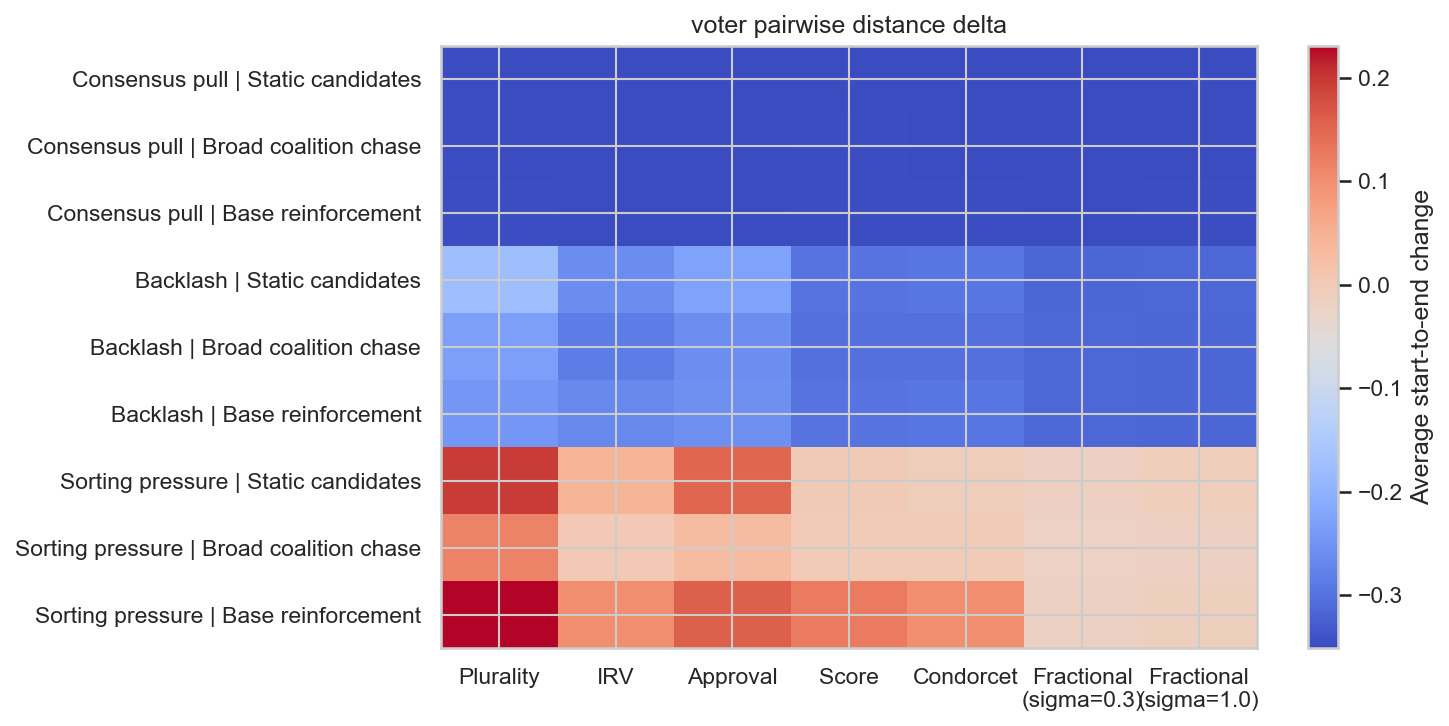

In [12]:
plot_polarization_metric_heatmap(
    comparison_df,
    metric_delta="voter_pairwise_distance_delta",
);

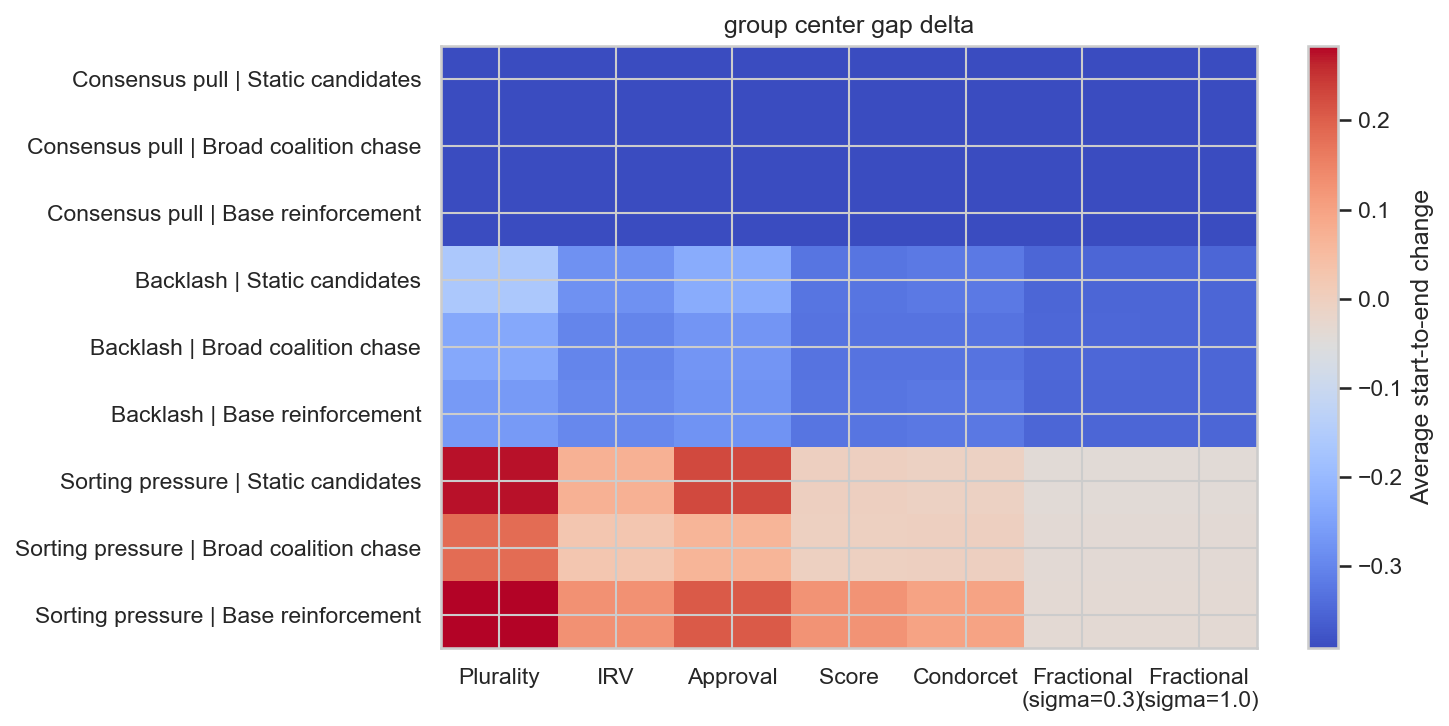

In [13]:
plot_polarization_metric_heatmap(
    comparison_df,
    metric_delta="group_center_gap_delta",
);

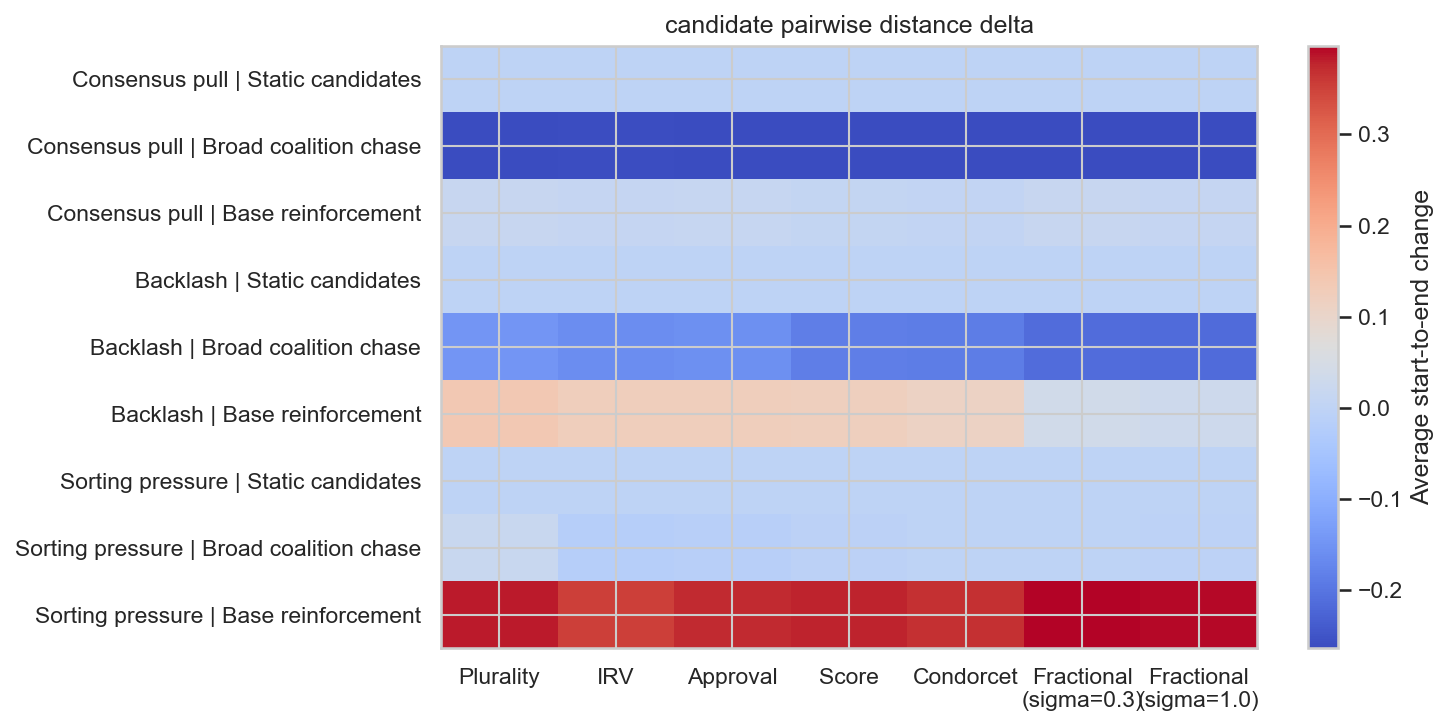

In [14]:
plot_polarization_metric_heatmap(
    comparison_df,
    metric_delta="candidate_pairwise_distance_delta",
);

### Two oracle benchmarks

The system comparisons above still leave one conceptual question open. Is choosing a winner that stays close to the electorate's geometric median basically the same thing as choosing a winner that most reduces polarization? The next section uses two unconstrained oracle benchmarks to separate those ideas.

Let $m^t$ be the electorate's geometric median at round $t$. The geometric-median oracle chooses

$$
w_{\mathrm{med}}^t \in \arg\min_{w \in [0,1]^2} \lVert w - m^t \rVert_2,
$$

which simply means it places the outcome at the geometric median.

For polarization, the notebook uses the same variance-style object that tracks how spread out the electorate is:

$$
D^t = \frac{1}{n}\sum_{i=1}^n \lVert x_i^t - \bar{x}^t \rVert_2^2.
$$

The depolarization oracle then chooses

$$
w_{\mathrm{dep}}^t \in \arg\min_{w \in [0,1]^2} D^{t+1}(w),
$$

where $D^{t+1}(w)$ is computed by applying the notebook's voter update rule for one step with outcome $w$ and with the random noise term turned off inside the objective.

A single case can make the two oracles look closer than they really are, so this section now shows two stressed examples side by side in spirit but separated clearly in presentation. One uses a `70:30` camp balance and the other uses `50:50`. That makes it easier to see whether the divergence is tied mainly to the feedback mechanism or also to the camp balance.

,case,system,distance_to_median_end,winner_to_center_distance_end,voter_pairwise_distance_end,candidate_pairwise_distance_end,normalized_displacement_asymmetry_end
1,Moderate divergence,Depolarization oracle,0.020594,0.017847,0.298010,0.764069,0.181348
0,Moderate divergence,Geometric median oracle,0.000000,0.014651,0.294832,0.740492,-0.106607
3,Sharp divergence,Depolarization oracle,0.472979,0.479819,0.398282,0.754306,0.060330
2,Sharp divergence,Geometric median oracle,0.000000,0.037603,0.387027,0.753938,0.162345


Moderate divergence: Bridge conflict | 50:50 | Asymmetric insurgency | Sorting pressure | Base reinforcement
Sharp divergence: Asymmetric resentment | 50:50 | Polarized elites | Sorting pressure | Base reinforcement


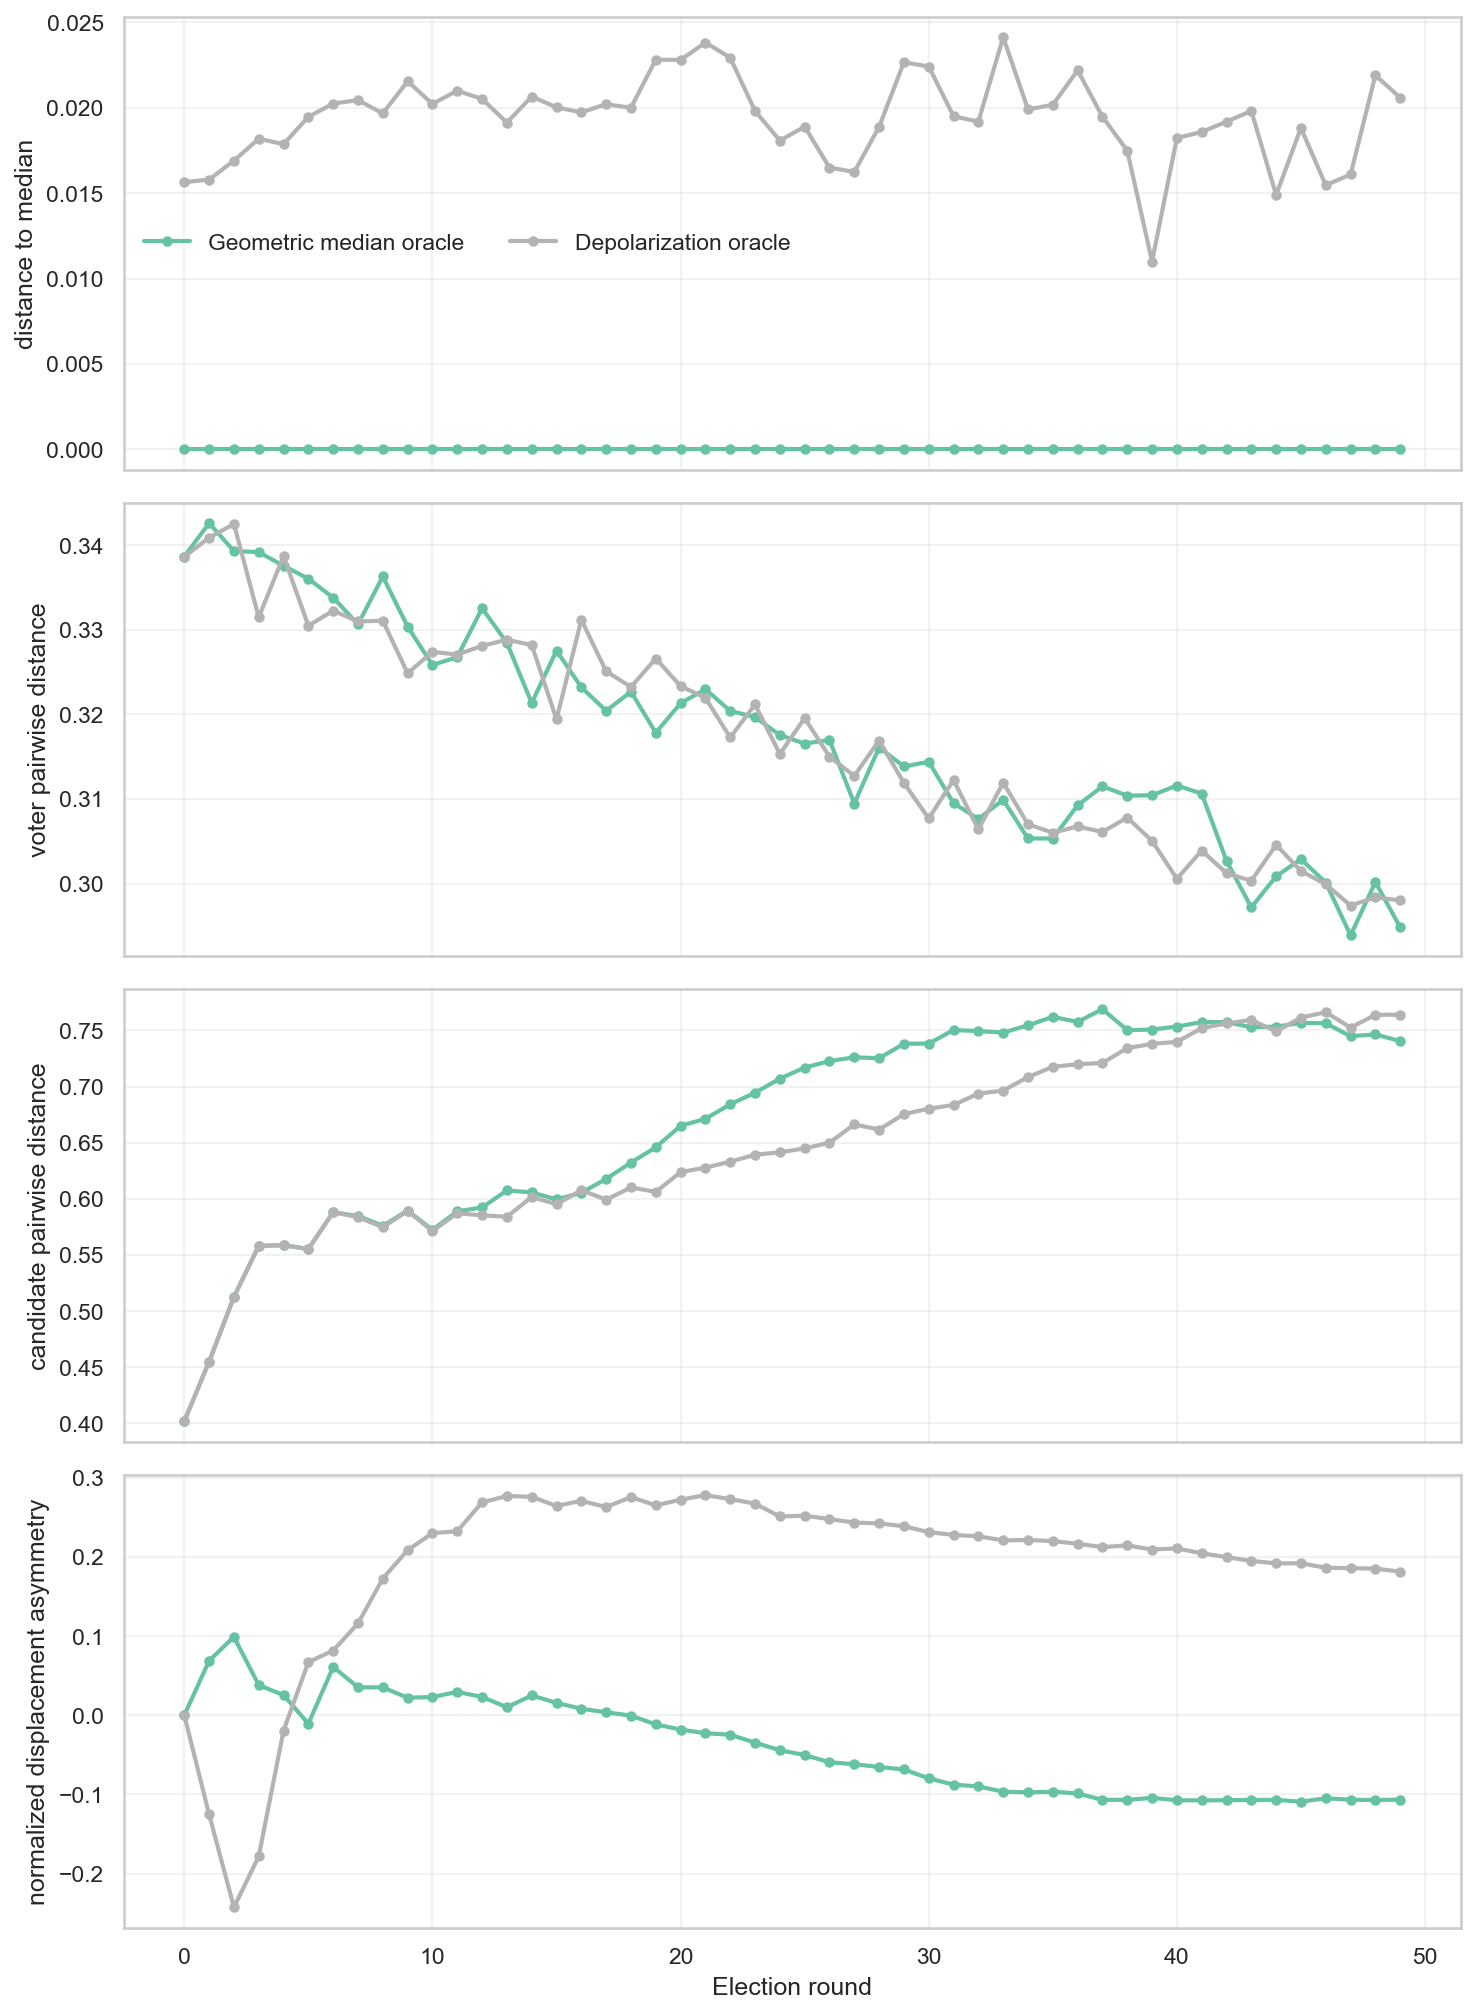

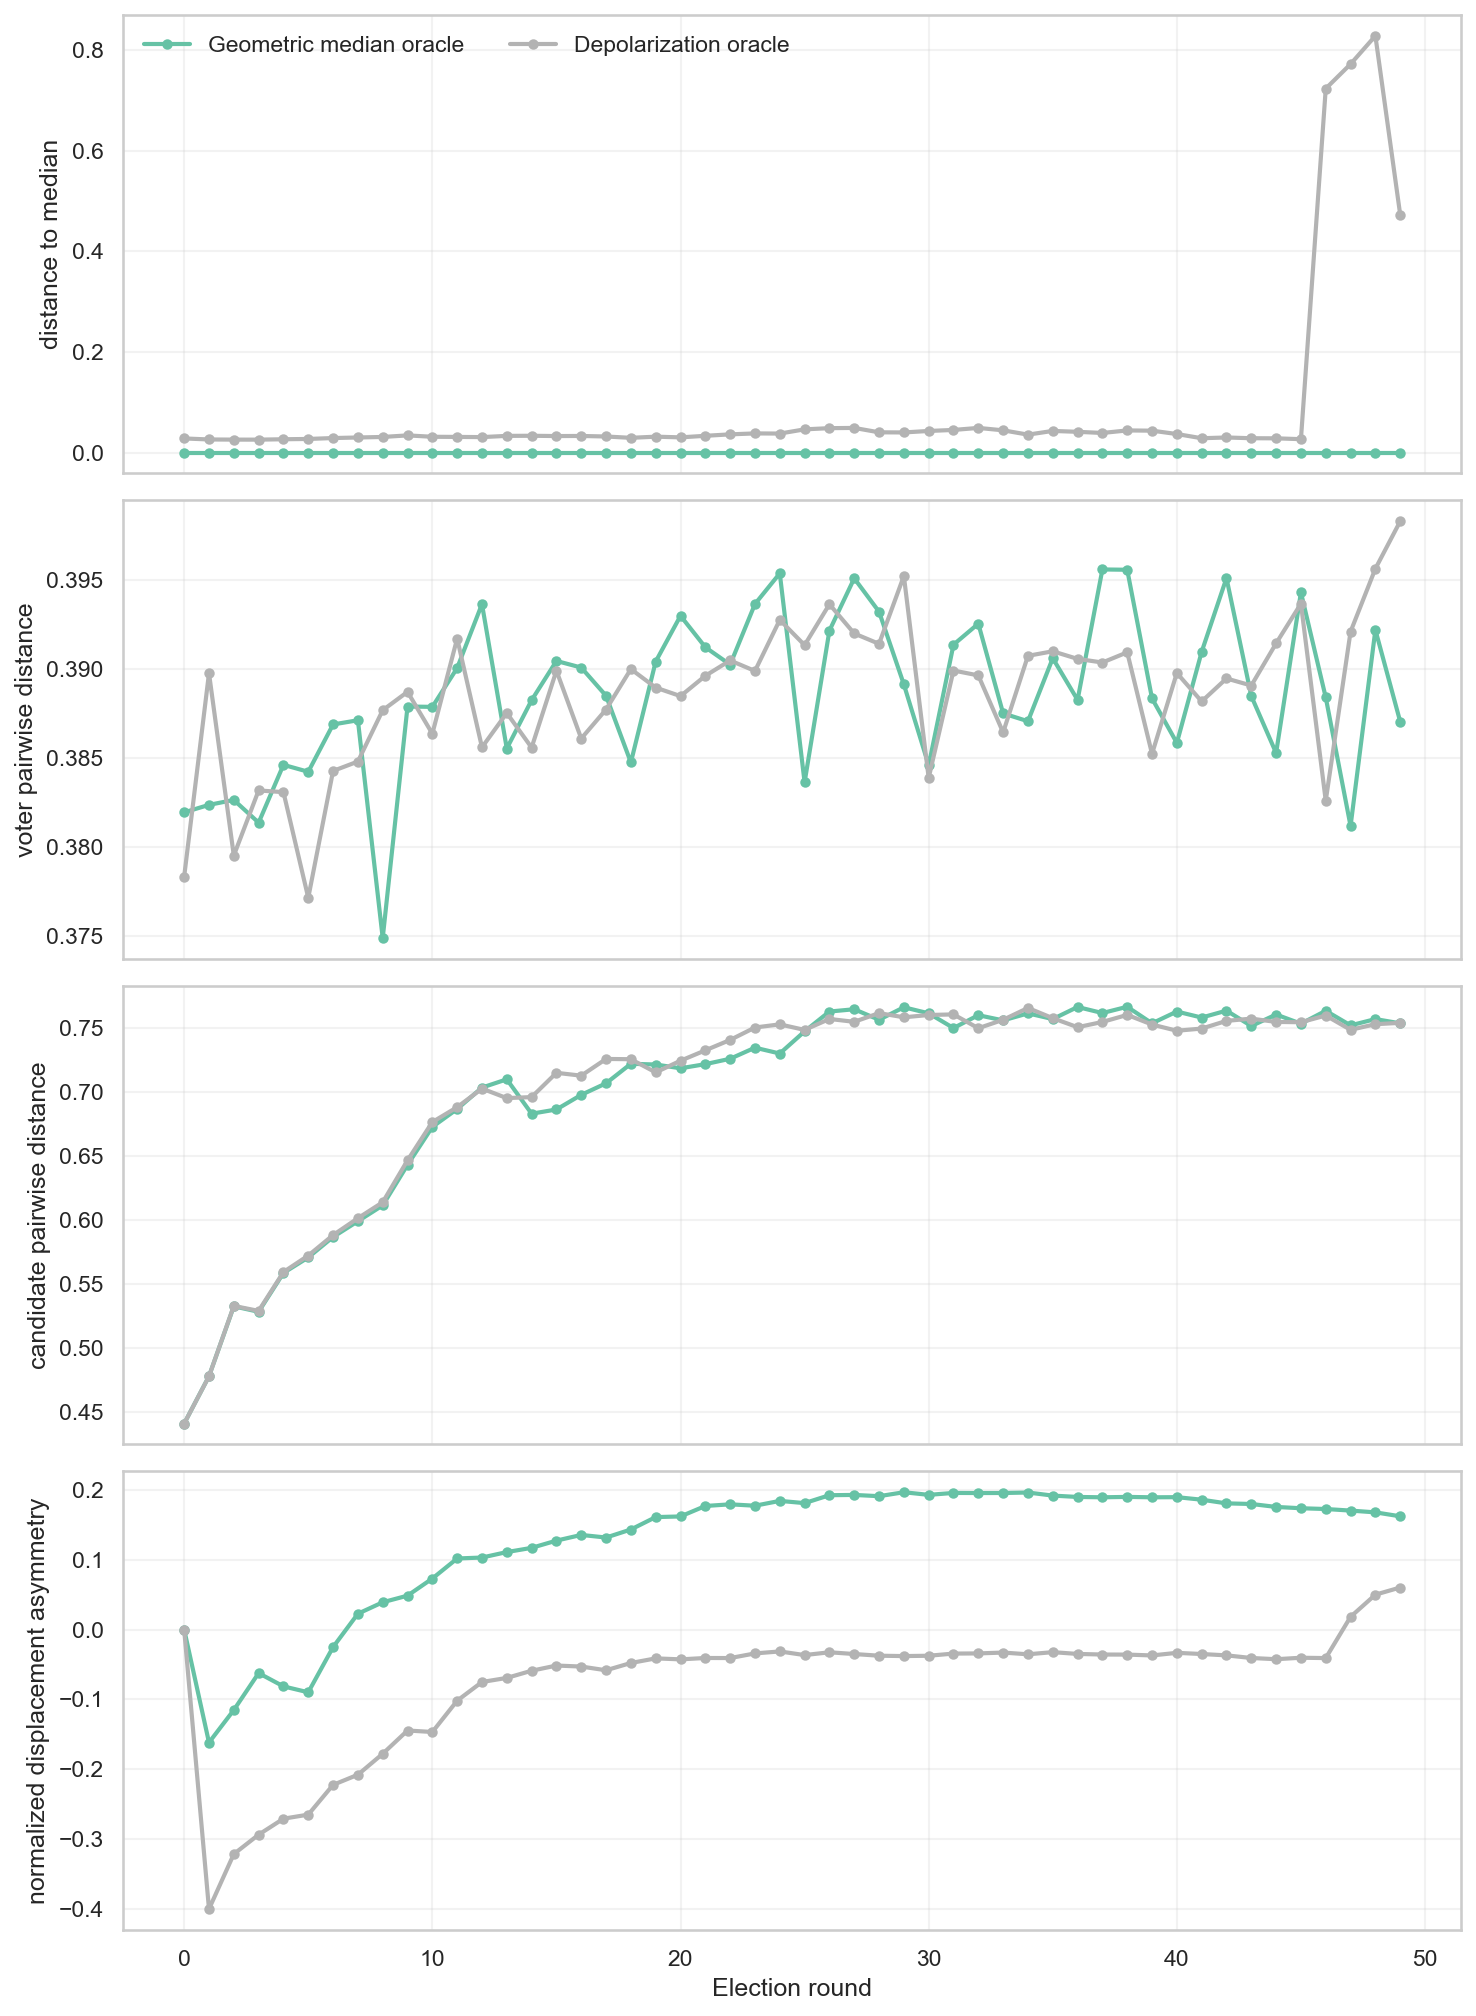

In [26]:
from IPython.display import Markdown

oracle_cases = [
    {
        "label": "Case A: 70:30 balance",
        "electorate": "Bridge conflict",
        "ratio": "70:30",
        "candidate_slate": "Polarized elites",
        "voter_dynamics": "Sorting pressure",
        "candidate_dynamics": "Base reinforcement",
        "seed": BASE_SEED + 120,
    },
    {
        "label": "Case B: 50:50 balance",
        "electorate": "Asymmetric resentment",
        "ratio": "50:50",
        "candidate_slate": "Polarized elites",
        "voter_dynamics": "Sorting pressure",
        "candidate_dynamics": "Base reinforcement",
        "seed": BASE_SEED + 220,
    },
]

oracle_results = []
for case in oracle_cases:
    electorate = build_polarization_electorate(
        case["electorate"],
        seed=case["seed"],
        dim_names=DIM_NAMES,
        n_voters=900,
        ratio_name=case["ratio"],
    )
    candidates = build_polarization_candidates(case["candidate_slate"])
    trajectory = run_oracle_trajectory(
        electorate,
        candidates,
        oracle_names=ORACLE_ORDER,
        n_steps=50,
        voter_dynamics=case["voter_dynamics"],
        candidate_dynamics=case["candidate_dynamics"],
        electorate_name=case["electorate"],
        ratio_name=case["ratio"],
        seed=case["seed"] + 1,
    )
    summary = summarize_trajectory_changes(trajectory)
    summary.insert(0, "case", case["label"])
    oracle_results.append((case, electorate, candidates, trajectory, summary))

for case, _, _, _, summary in oracle_results:
    display(Markdown(f"#### {case['label']}"))
    display(Markdown(
        f"Electorate: `{case['electorate']}`  \nRatio: `{case['ratio']}`  \nCandidate slate: `{case['candidate_slate']}`  \n"
        f"Voter mechanism: `{case['voter_dynamics']}`  \nCandidate mechanism: `{case['candidate_dynamics']}`"
    ))
    display(
        summary[[
            "system",
            "distance_to_median_end",
            "winner_to_center_distance_end",
            "voter_pairwise_distance_end",
            "candidate_pairwise_distance_end",
            "normalized_displacement_asymmetry_end",
        ]].sort_values("system")
    )


Moderate divergence: spatial path
Sharp divergence: spatial path


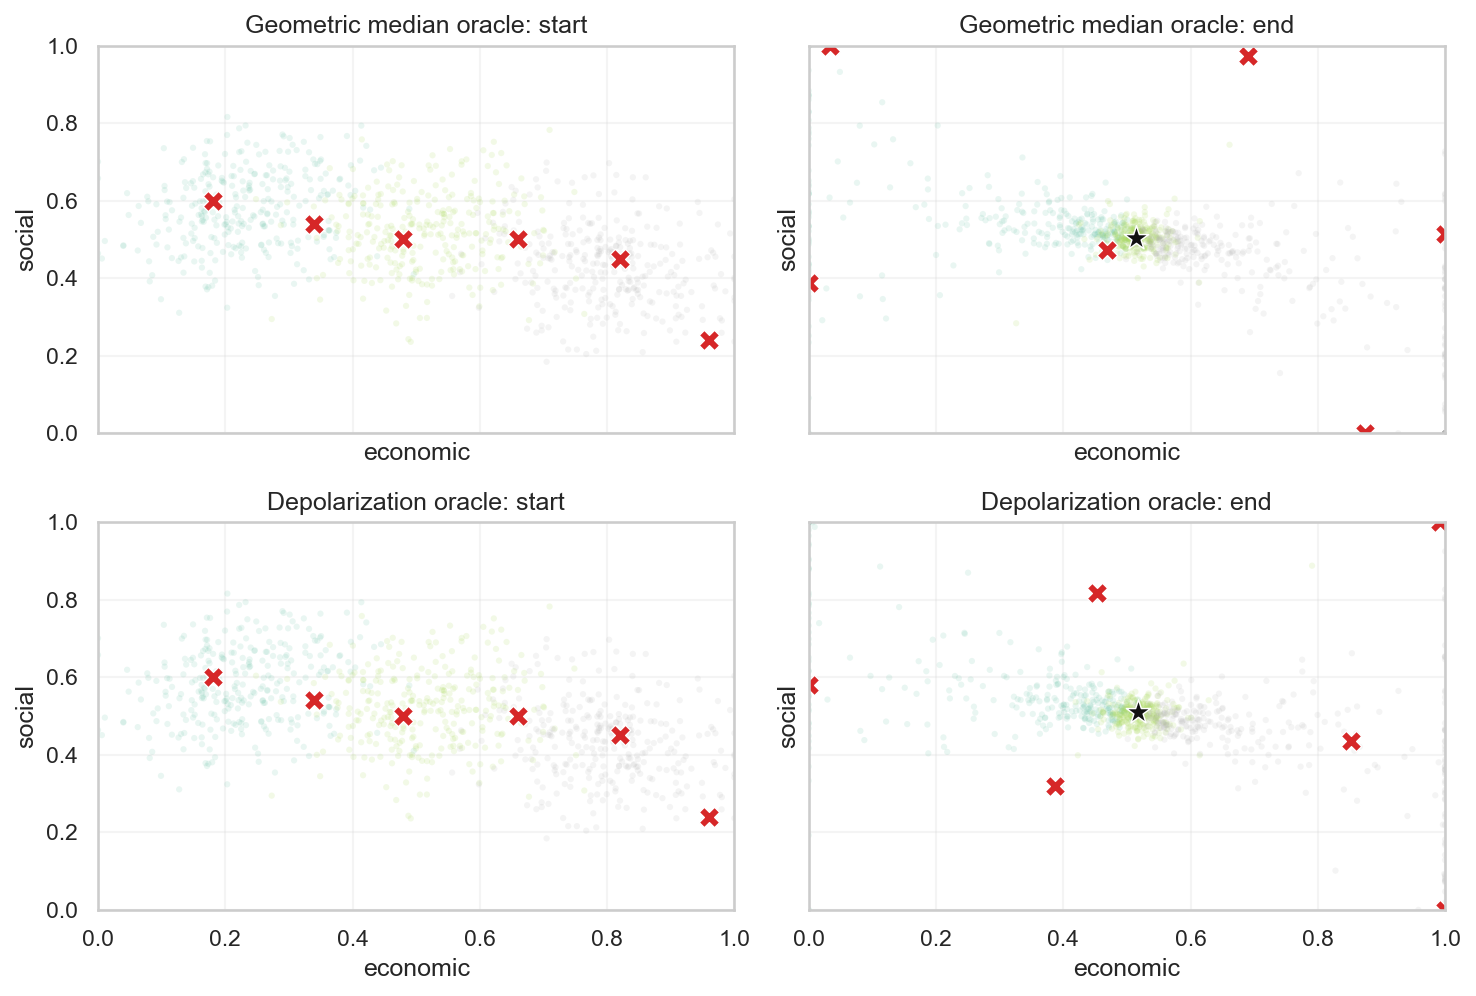

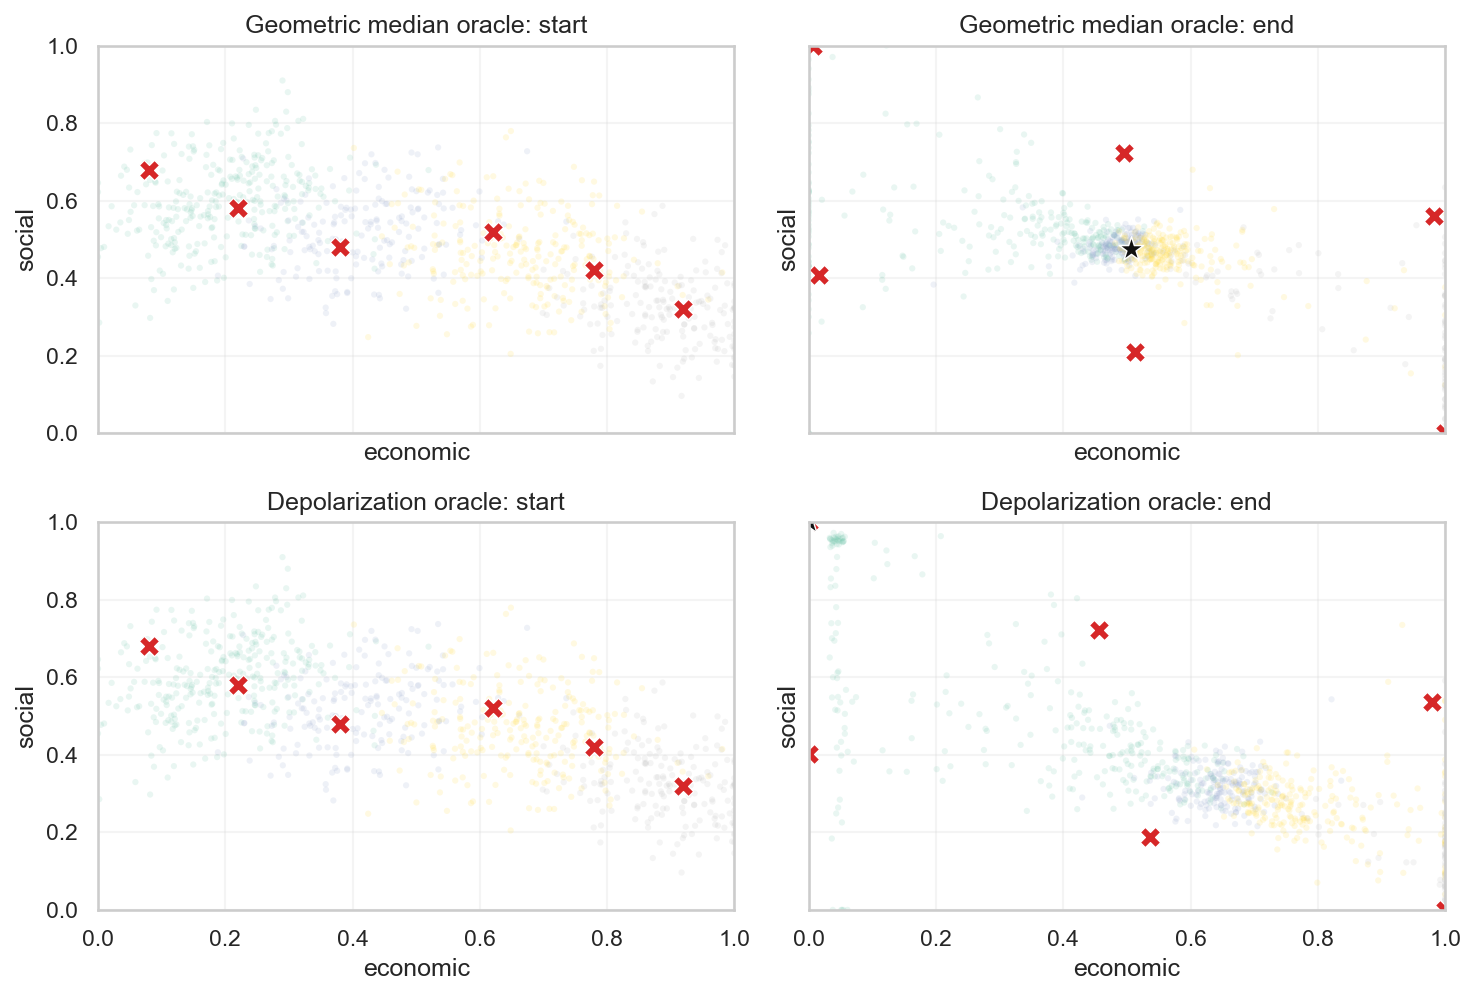

In [27]:
for case, electorate, candidates, trajectory, _ in oracle_results:
    display(Markdown(f"#### {case['label']}: trajectories"))
    plot_polarization_trajectories(
        trajectory,
        metrics=[
            "distance_to_median",
            "voter_pairwise_distance",
            "candidate_pairwise_distance",
            "normalized_displacement_asymmetry",
        ],
    );

    display(Markdown(f"#### {case['label']}: spatial path"))
    oracle_state_map = {
        oracle_name: trace_oracle_state(
            electorate,
            candidates,
            oracle_name=oracle_name,
            n_steps=50,
            voter_dynamics=case["voter_dynamics"],
            candidate_dynamics=case["candidate_dynamics"],
            seed=case["seed"] + 2 + 10 * idx,
        )
        for idx, oracle_name in enumerate(ORACLE_ORDER)
    }
    plot_oracle_start_end_maps(oracle_state_map, ORACLE_ORDER);


In the `70:30` case, the two oracles differ, but the main change is in asymmetry and winner-centering. In the `50:50` case, the depolarization oracle can pull much farther away from the geometric median, which makes the tradeoff much harder to miss. That side-by-side structure makes the core lesson easier to see: geometric centering and polarization control are related goals, but they are not the same optimization problem.

### Does the depolarization story change with camp balance?

This is the new design question. If a system looks depolarizing only because the smaller camp is being pulled much farther than the larger camp, that should show up most clearly when the camps start out at `70:30`, and it should weaken when they start at `50:50`.

The next summaries therefore separate two ideas:

- raw depolarization, measured by the change in voter pairwise distance,
- asymmetry, measured by the end-of-run normalized displacement imbalance.

For the asymmetry measure, values near zero mean the two camps moved by similar amounts. Positive values mean the smaller camp moved more than the larger camp.

In [17]:
ratio_focus_summary.sort_values(["ratio", "mean_voter_pairwise_delta"]).reset_index(drop=True)

,ratio,system,mean_voter_pairwise_delta,mean_normalized_displacement_asymmetry_end,mean_coalition_midpoint_drift_end
0,50:50,Fractional (sigma=0.3),-0.230294,0.029863,0.015327
1,50:50,Fractional (sigma=1.0),-0.230233,0.028284,0.018346
2,50:50,Condorcet,-0.203880,0.041360,0.075670
3,50:50,Score,-0.199222,0.048770,0.061119
4,50:50,IRV,-0.185616,0.030979,0.108559
5,50:50,Approval,-0.137358,0.023000,0.098634
6,50:50,Plurality,-0.095511,-0.000085,0.084780
7,70:30,Fractional (sigma=0.3),-0.223042,0.170920,0.054259
8,70:30,Fractional (sigma=1.0),-0.218288,0.209774,0.047119
9,70:30,Score,-0.203612,0.266918,0.113957


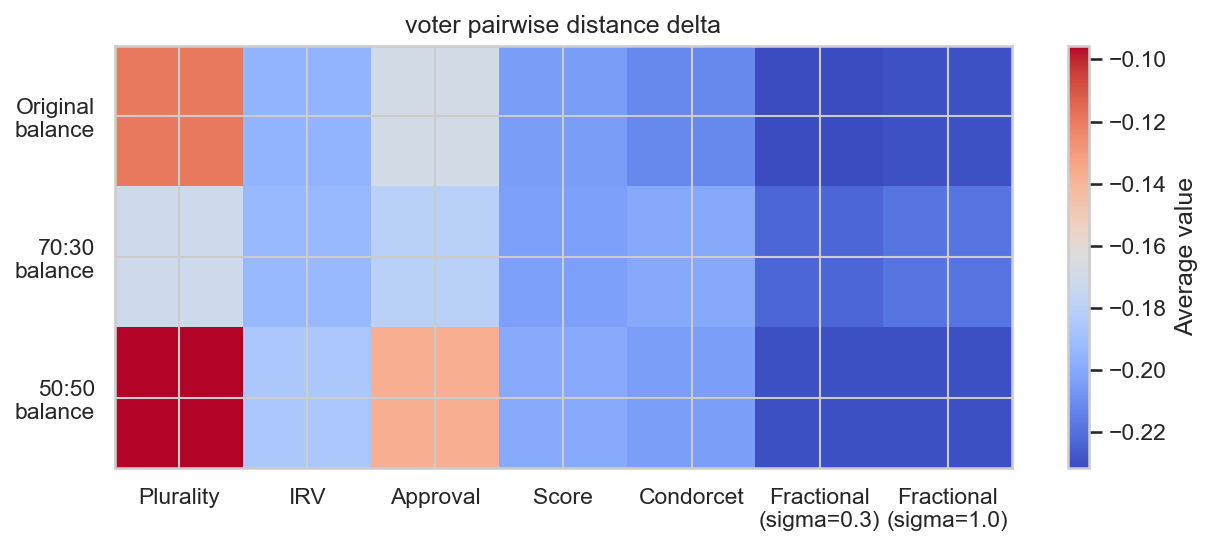

In [18]:
plot_ratio_system_heatmap(comparison_df, metric="voter_pairwise_distance_delta");

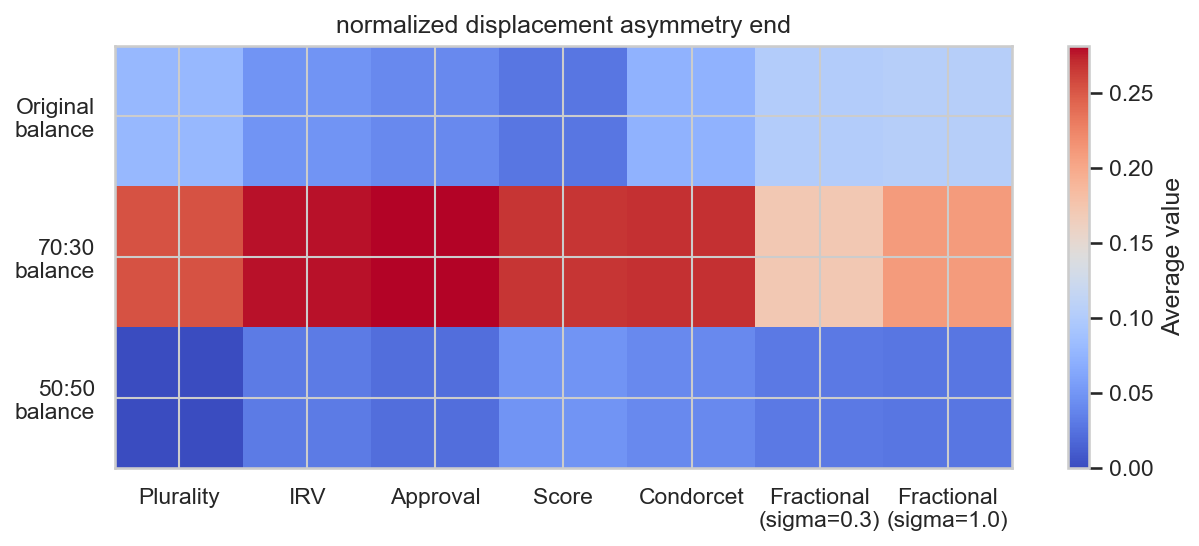

In [19]:
plot_ratio_system_heatmap(comparison_df, metric="normalized_displacement_asymmetry_end");

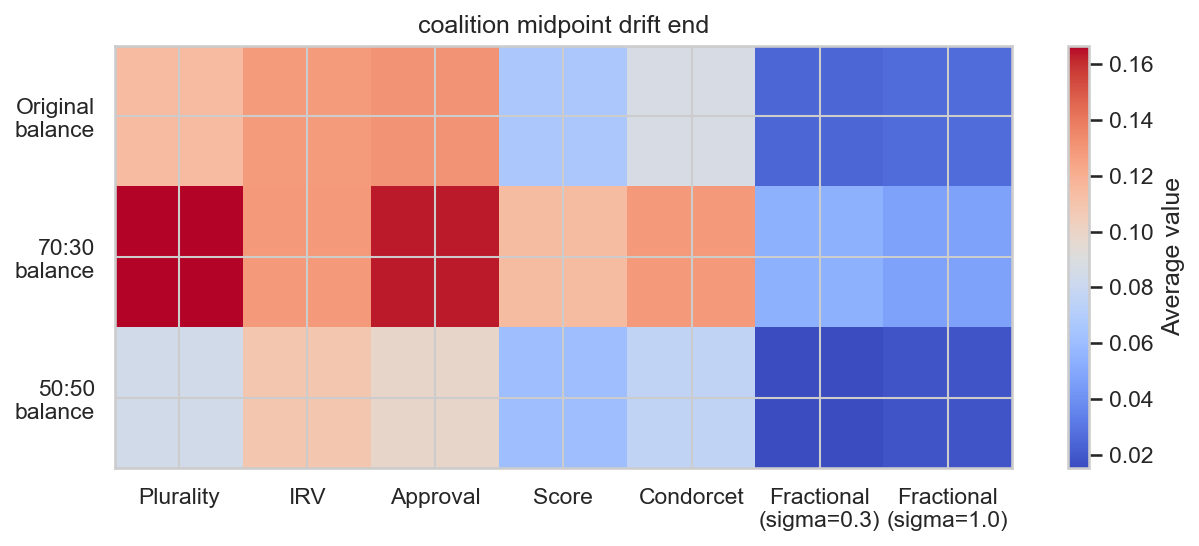

In [20]:
plot_ratio_system_heatmap(comparison_df, metric="coalition_midpoint_drift_end");

### Winner-centering over repeated elections

This section looks at a different question: if these same systems are run repeatedly, do their winners stay close to the electorate center? That is a representation question rather than a depolarization question.

Again, more negative values are better. A negative winner-to-center change means the eventual winner ends up closer to the electorate center than at the start of the trajectory.

In [21]:
representation_summary

,system,mean_winner_center_delta,mean_distance_to_median_delta
0,Approval,-0.102632,-0.109518
1,Plurality,-0.093391,-0.102021
2,IRV,-0.058421,-0.073278
3,Fractional (sigma=1.0),-0.012893,-0.043595
4,Score,-0.010414,-0.014739
5,Fractional (sigma=0.3),-0.007126,-0.033237
6,Condorcet,-0.004833,-0.008555


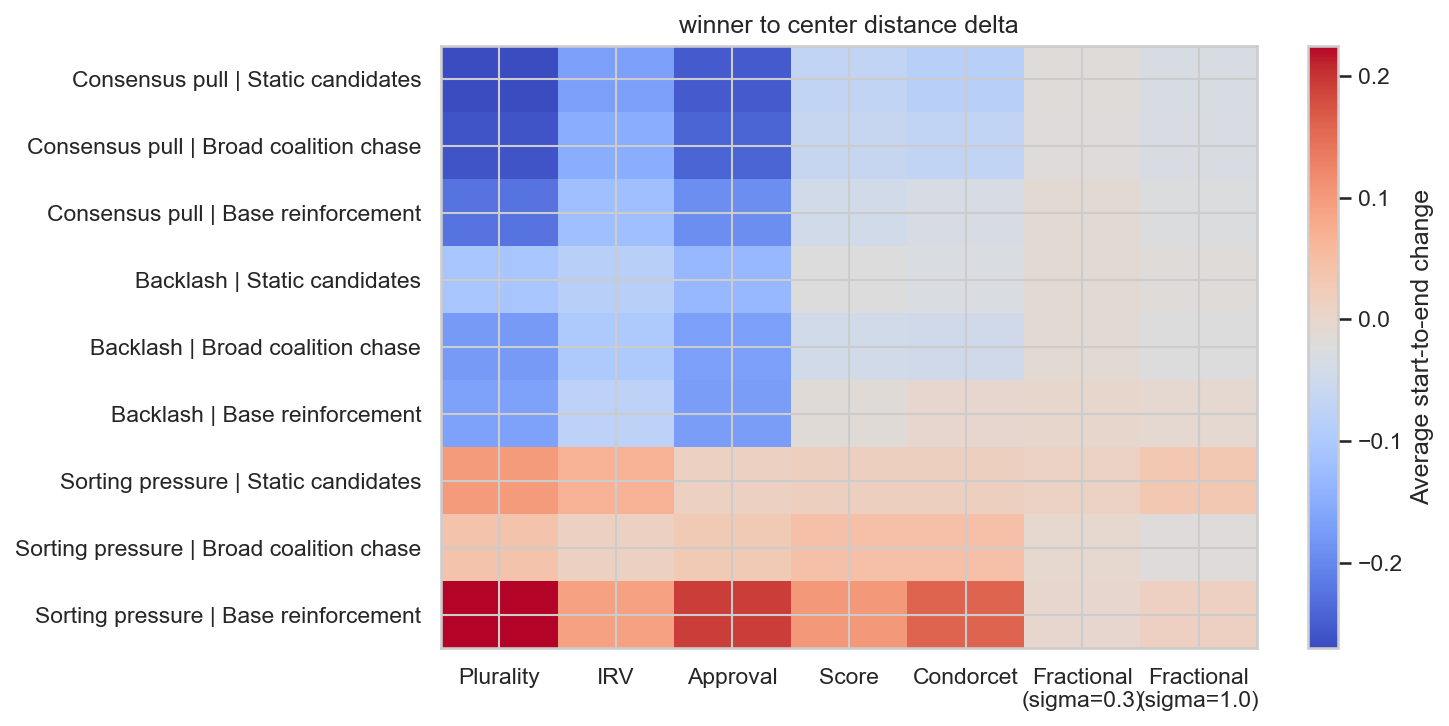

In [22]:
plot_polarization_metric_heatmap(
    comparison_df,
    metric_delta="winner_to_center_distance_delta",
);

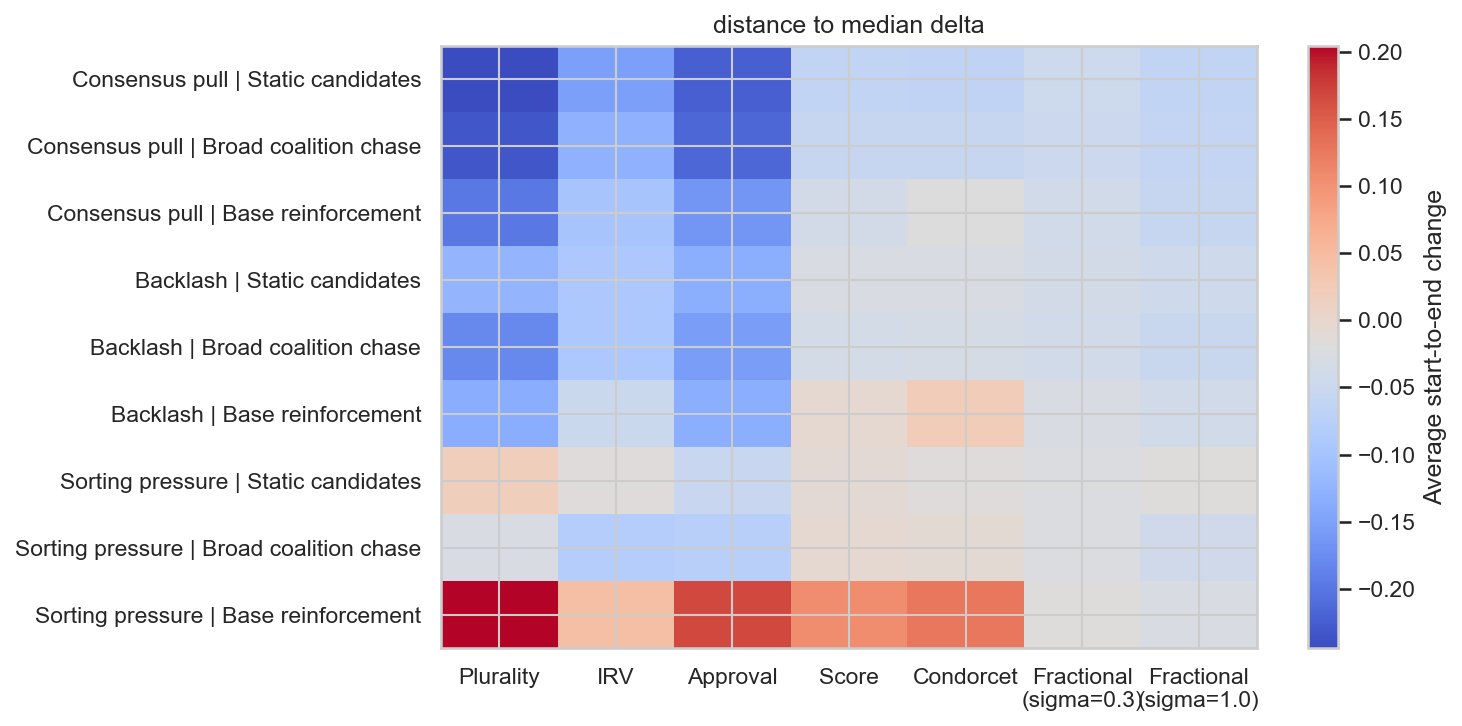

In [23]:
plot_polarization_metric_heatmap(
    comparison_df,
    metric_delta="distance_to_median_delta",
);

### Putting the tradeoff in one picture

The scatter plot below treats mean voter depolarization and mean winner-centering as separate axes. Systems in the lower-left corner are doing well on both dimensions. Systems far to the left but higher up are good at cooling the electorate but weaker at keeping winners centered. Systems lower down but closer to zero on the x-axis are better at winner-centering than at long-run depolarization.

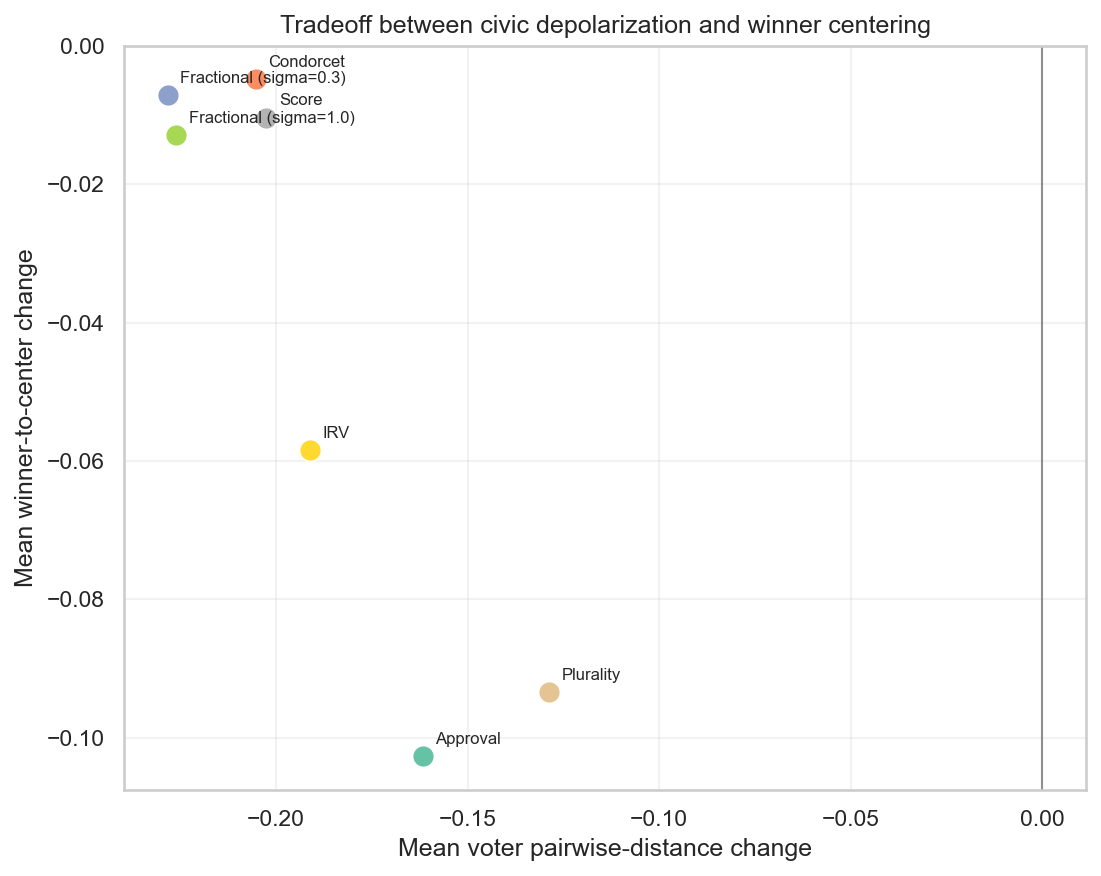

In [24]:
plot_polarization_tradeoff_scatter(system_summary);

### Conclusion

After 50 rounds the fractional benchmarks are the most reliable depolarizers on voter-to-voter spread, `Condorcet` and `Score` usually follow, and plurality looks weakest once camp balance is not doing the work for it. The balance split still matters because `70:30` cases generate more asymmetric movement than `50:50` cases under almost every rule.

The oracle comparisons make it clear that an outcome rule that hugs the geometric median each round is not the same thing as an outcome rule that most reduces next-round polarization, and over repeated elections those two goals can pull the electorate and candidate field in visibly different directions. So the notebook still points to tradeoffs rather than a single universal winner.